# Notebook 3 - Trekveren

Deze notebook gebruikt dezelfde kinematica, massa's en Newton-Euler-opbouw als Notebook 3, maar voegt een trekveerpakket toe als bekende externe kracht op de schuiver/collar. De bedoeling is een directe vergelijking tussen de belasting zonder veer en met veer.

De veeropstelling is bewust eenvoudig: twee symmetrische trekveren parallel aan de mast, links en rechts van de schuiver. Ze trekken de schuiver omhoog en zitten niet in de riem of kabel. De riem blijft dus alleen de actieve aandrijving; de schuivergeleiding en mast blijven de zijreacties dragen.

Workflow:

1. Run `Notebook 1.ipynb` voor de kinematica.
2. Run `Notebook 2.ipynb` voor de inertie-only dynamica en massa's.
3. Run `Notebook 3.ipynb` voor de baseline zonder trekveren.
4. Run deze notebook voor de trekveer-case.
5. Run `Notebook 4.ipynb` met `load_case = "trekveren"` om motor, riem, poelie en rem te dimensioneren voor deze case.


## Setup en data

De notebook leest `notebook1_kinematica_results.npz`, `notebook2_dynamica_results.npz` en de baseline `notebook3_gravity_friction_results.npz`. De baseline wordt niet overschreven; ze wordt alleen gebruikt als referentie om de trekveer automatisch te schalen en om de resultaten te vergelijken.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

kinematics_path = Path("notebook1_kinematica_results.npz")
dynamics_path = Path("notebook2_dynamica_results.npz")
if not kinematics_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 1.ipynb' zodat notebook1_kinematica_results.npz bestaat.")
if not dynamics_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 2.ipynb' zodat notebook2_dynamica_results.npz bestaat.")

kin_required = [
    "t", "Ts", "s", "ds", "dds",
    "theta3", "theta4", "theta5", "theta6", "theta7", "theta8",
    "dtheta3", "dtheta4", "dtheta5", "dtheta6", "dtheta7", "dtheta8",
    "ddtheta3", "ddtheta4", "ddtheta5", "ddtheta6", "ddtheta7", "ddtheta8",
    "Kx", "Ky", "Kdot_x", "Kdot_y", "Kdot_norm", "Kddot_x", "Kddot_y", "Kddot_norm",
    "cond", "residual_pos",
    "L1", "r3a", "r3b", "r4a", "r4b", "r5a", "r5b", "r6", "r7a", "r7b", "r8a", "r8b",
]
dyn_required = [
    "F_drive_s", "R_Ax", "C_x", "C_y", "M_A", "w_all", "unknown_labels",
    "masses", "inertias", "payload_mass_K", "line_mass_density", "slider_mass", "total_model_mass",
]
kin = np.load(kinematics_path)
dyn = np.load(dynamics_path, allow_pickle=True)
missing_kin = [key for key in kin_required if key not in kin.files]
missing_dyn = [key for key in dyn_required if key not in dyn.files]
if missing_kin:
    raise KeyError(f"Ontbrekende keys in {kinematics_path}: {missing_kin}")
if missing_dyn:
    raise KeyError(f"Ontbrekende keys in {dynamics_path}: {missing_dyn}")

t = kin["t"]; Ts = float(kin["Ts"]); s = kin["s"]; ds = kin["ds"]; dds = kin["dds"]
n_steps = len(t); T_cycle = float(t[-1] - t[0])
theta3 = kin["theta3"]; theta4 = kin["theta4"]; theta5 = kin["theta5"]
theta6 = kin["theta6"]; theta7 = kin["theta7"]; theta8 = kin["theta8"]
dtheta3 = kin["dtheta3"]; dtheta4 = kin["dtheta4"]; dtheta5 = kin["dtheta5"]
dtheta6 = kin["dtheta6"]; dtheta7 = kin["dtheta7"]; dtheta8 = kin["dtheta8"]
ddtheta3 = kin["ddtheta3"]; ddtheta4 = kin["ddtheta4"]; ddtheta5 = kin["ddtheta5"]
ddtheta6 = kin["ddtheta6"]; ddtheta7 = kin["ddtheta7"]; ddtheta8 = kin["ddtheta8"]
Kx = kin["Kx"]; Ky = kin["Ky"]; Kdot_x = kin["Kdot_x"]; Kdot_y = kin["Kdot_y"]
Kdot_norm = kin["Kdot_norm"]; Kddot_x = kin["Kddot_x"]; Kddot_y = kin["Kddot_y"]; Kddot_norm = kin["Kddot_norm"]
cond = kin["cond"]; residual_pos = kin["residual_pos"]
L1 = float(kin["L1"]); r3a = float(kin["r3a"]); r3b = float(kin["r3b"])
r4a = float(kin["r4a"]); r4b = float(kin["r4b"]); r5a = float(kin["r5a"]); r5b = float(kin["r5b"])
r6 = float(kin["r6"]); r7a = float(kin["r7a"]); r7b = float(kin["r7b"]); r8a = float(kin["r8a"]); r8b = float(kin["r8b"])
L2 = 0.0; L3 = r3a + r3b; L4 = r4a + r4b; L5 = r5a + r5b; L6 = r6; L7 = r7a + r7b; L8 = r8a + r8b

unknown_labels = [str(x) for x in dyn["unknown_labels"]]
unknown_index = {name: i for i, name in enumerate(unknown_labels)}
n_unknowns = len(unknown_labels)
w_inertia_notebook2 = dyn["w_all"]
F_drive_s_inertia = dyn["F_drive_s"]
R_Ax_inertia = dyn["R_Ax"]
C_x_inertia = dyn["C_x"]; C_y_inertia = dyn["C_y"]; M_A_inertia = dyn["M_A"]
mass_array = dyn["masses"].astype(float); inertia_array = dyn["inertias"].astype(float)
masses = {link_id: mass_array[link_id - 2] for link_id in range(2, 9)}
inertias = {link_id: inertia_array[link_id - 2] for link_id in range(2, 9)}
payload_mass_K = float(dyn["payload_mass_K"])
line_mass_density = float(dyn["line_mass_density"])
slider_mass = float(dyn["slider_mass"])
rod_outer_diameter = float(dyn["rod_outer_diameter"]) if "rod_outer_diameter" in dyn.files else np.nan
rod_wall_thickness = float(dyn["rod_wall_thickness"]) if "rod_wall_thickness" in dyn.files else np.nan
rod_inner_diameter = float(dyn["rod_inner_diameter"]) if "rod_inner_diameter" in dyn.files else np.nan
rod_material_density = float(dyn["rod_material_density"]) if "rod_material_density" in dyn.files else np.nan
rod_tube_area = float(dyn["rod_tube_area"]) if "rod_tube_area" in dyn.files else np.nan
rod_tube_mass_per_m = float(dyn["rod_tube_mass_per_m"]) if "rod_tube_mass_per_m" in dyn.files else np.nan
rod_fittings_line_mass_allowance = float(dyn["rod_fittings_line_mass_allowance"]) if "rod_fittings_line_mass_allowance" in dyn.files else np.nan
total_model_mass = float(dyn["total_model_mass"])

expected_labels = [
    "R_Ax", "F_act_y", "M_A", "C_x", "C_y", "B_x", "B_y", "D_x", "D_y", "E_x", "E_y",
    "F_x", "F_y", "G_x", "G_y", "H_x", "H_y", "I_x", "I_y", "J_x", "J_y",
]
if unknown_labels != expected_labels:
    raise ValueError("De onbekenden uit Notebook 2 hebben niet de verwachte volgorde.")

print("Data ingeladen:")
print(kinematics_path.resolve())
print(dynamics_path.resolve())
print(f"Aantal tijdstappen: {n_steps}")
print(f"Totale simulatieduur: {T_cycle:.3f} s")
print(f"Totale bewegende modelmassa incl. K: {total_model_mass:.3f} kg")
print(f"Puntmassa K: {payload_mass_K:.3f} kg")
print(f"max sluitingsfout Notebook 1: {np.max(residual_pos):.3e}")

baseline_path = Path("notebook3_gravity_friction_results.npz")
if not baseline_path.exists():
    raise FileNotFoundError("Run eerst 'Notebook 3.ipynb' zodat notebook3_gravity_friction_results.npz bestaat.")

baseline_required = [
    "t", "s", "ds", "dds",
    "F_drive_s_inertia", "F_drive_s_gravity", "F_drive_s_total",
    "F_gravity_component", "F_friction_component", "F_slider_drive_component", "F_pin_friction_component",
    "P_act_total", "E_act_total",
    "hold_s_curve", "F_hold_s_curve", "R_Ax_hold_curve", "static_slider_capacity_curve",
    "R_Ax_total", "C_x_total", "C_y_total", "F_A_total_norm", "F_C_total_norm", "F_frame_total_norm",
    "A_max_full", "P_avg_full", "P_peak_full", "P_rms_full", "F_peak_full", "F_rms_full",
    "total_weight", "dyn_residual_total", "max_diff_notebook2",
]
baseline = np.load(baseline_path, allow_pickle=True)
missing_baseline = [key for key in baseline_required if key not in baseline.files]
if missing_baseline:
    raise KeyError(f"Ontbrekende keys in {baseline_path}: {missing_baseline}")

for key in ["t", "s", "ds", "dds"]:
    if not np.allclose(locals()[key], baseline[key], rtol=0.0, atol=1e-10):
        raise ValueError(f"De tijdbasis/kinematica wijkt af van Notebook 3 voor key '{key}'. Run Notebook 1 -> 2 -> 3 opnieuw.")

F_drive_s_baseline = baseline["F_drive_s_total"]
F_drive_s_gravity_baseline = baseline["F_drive_s_gravity"]
F_gravity_component_baseline = baseline["F_gravity_component"]
F_friction_component_baseline = baseline["F_friction_component"]
F_slider_drive_component_baseline = baseline["F_slider_drive_component"]
F_pin_friction_component_baseline = baseline["F_pin_friction_component"]
P_act_baseline = baseline["P_act_total"]
E_act_baseline = baseline["E_act_total"]
hold_s_baseline_curve = baseline["hold_s_curve"]
F_hold_s_baseline_curve = baseline["F_hold_s_curve"]
R_Ax_hold_baseline_curve = baseline["R_Ax_hold_curve"]
static_slider_capacity_baseline_curve = baseline["static_slider_capacity_curve"]
R_Ax_baseline = baseline["R_Ax_total"]
C_x_baseline = baseline["C_x_total"]
C_y_baseline = baseline["C_y_total"]
F_A_baseline_norm = baseline["F_A_total_norm"]
F_C_baseline_norm = baseline["F_C_total_norm"]
F_frame_baseline_norm = baseline["F_frame_total_norm"]

print("Baseline zonder trekveren ingeladen:")
print(baseline_path.resolve())
print(f"max |F_s| baseline tijdens beweging: {np.max(np.abs(F_drive_s_baseline[np.abs(ds) > 1e-8])):.3f} N")
print(f"max |F_hold| baseline             : {np.max(np.abs(F_hold_s_baseline_curve)):.3f} N")


Data ingeladen:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook1_kinematica_results.npz
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook2_dynamica_results.npz
Aantal tijdstappen: 481
Totale simulatieduur: 24.000 s
Totale bewegende modelmassa incl. K: 7.500 kg
Puntmassa K: 3.000 kg
max sluitingsfout Notebook 1: 4.718e-13
Baseline zonder trekveren ingeladen:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook3_gravity_friction_results.npz
max |F_s| baseline tijdens beweging: 74.892 N
max |F_hold| baseline             : 63.432 N


## Parameters

Positieve `s` wijst naar beneden. Openen betekent meestal `ds < 0`. De trekveren trekken de schuiver omhoog, dus in globale `y`-richting positief. In `s`-richting is de veerkracht daardoor negatief.

De standaardinstelling compenseert bewust maar een deel van de baseline-houdkracht. Zo helpt de veer bij openen, maar blijft het systeem controleerbaar en moet de rem/motor nog steeds elke tussenstand kunnen vasthouden.


In [2]:

with_gravity = True
g = 9.81
g_vec = np.array([0.0, -g])

# Schuivergeleiding. Voor een outdoor collar met rollen/glijblokken is de effectieve
# wrijving typisch lager dan droge metaal-op-metaal, maar hoger dan ideale kogellagers.
# Bronorde: droge kunststof/staal glijgeleidingen ca. 0.05-0.23; daarom kiezen we
# dynamisch 0.08 en statisch 0.12 als realistische, conservatieve basis.
mu_slider = 0.08
mu_slider_static = 0.12
c_slider = 0.0
v_eps = 1e-3

# Scharnier-/buswrijving. Eenvoudige Coulomb-benadering met pinradius.
# mu_pin = 0.05 is een orde-waarde voor gesmeerde of lage-wrijving bus-/penscharniertjes.
include_pin_friction = True
mu_pin = 0.05
pin_radius = 0.006
omega_eps = 1e-3
friction_iterations = 20
friction_tol = 1e-8

actuator_efficiency = 0.78  # tandriem + reductiekast, zie Notebook 4
actuator_safety_factor = 1.50
drive_pulley_radius_nb3 = 0.025  # [m] referentiepoelie voor quick check; Notebook 4 kiest definitief
drive_travel_per_rev_nb3 = 2 * np.pi * drive_pulley_radius_nb3  # [m/omw] riemverplaatsing per poelie-omwenteling
pulley_radius_nb3 = drive_pulley_radius_nb3  # compatibility alias voor oudere outputs/tekst
screw_lead = drive_travel_per_rev_nb3  # compatibility alias; geen schroefspindel in dit ontwerp

# Trekveren: twee symmetrische veren parallel aan de mast/schuiver.
# De veren trekken de collar omhoog en zitten niet in de riem/kabel.
spring_count = 2
spring_design_mode = "fraction_of_baseline_hold"  # opties: "fraction_of_baseline_hold", "manual"
spring_assist_fraction_open = 0.60
spring_assist_fraction_closed = 0.70
spring_max_assist_fraction = 0.80

spring_force_open_total_manual = 20.0    # [N] totale veerkracht omhoog bij open stand
spring_force_closed_total_manual = 50.0  # [N] totale veerkracht omhoog bij gesloten stand

# Directe trekveer langs de mast. Geen kabel-/poelieverhouding: de veer volgt
# dezelfde slag als de schuiver. De waarde is laag maar realistisch voor een
# lange, slanke trekveer; compacte stijve veren zouden over deze slag overcompenseren.
spring_direct_rate_per_spring_N_per_mm = 0.010  # [N/mm] per trekveer
spring_physical_rate_per_spring_N_per_mm = spring_direct_rate_per_spring_N_per_mm  # compatibility alias
spring_motion_ratio = 1.0  # directe montage: dx_veer = ds_schuiver

if spring_count < 1:
    raise ValueError("spring_count moet minstens 1 zijn.")
if spring_design_mode not in ("fraction_of_baseline_hold", "manual"):
    raise ValueError("spring_design_mode moet 'fraction_of_baseline_hold' of 'manual' zijn.")
if not (0.0 < spring_max_assist_fraction < 1.0):
    raise ValueError("spring_max_assist_fraction moet tussen 0 en 1 liggen.")
if spring_assist_fraction_open < 0 or spring_assist_fraction_closed < 0:
    raise ValueError("Veerfracties moeten positief zijn.")
if spring_direct_rate_per_spring_N_per_mm <= 0:
    raise ValueError("spring_direct_rate_per_spring_N_per_mm moet positief zijn.")

print("Belastings- en veerparameters:")
print(f"g = {g:.2f} m/s^2")
print(f"mu_slider = {mu_slider:.3f}, mu_slider_static = {mu_slider_static:.3f}, c_slider = {c_slider:.2f} N s/m")
print(f"mu_pin = {mu_pin:.3f}, pin_radius = {pin_radius*1000:.1f} mm, scharnierwrijving actief = {include_pin_friction}")
print(f"friction_iterations = {friction_iterations}, friction_tol = {friction_tol:.0e}")
print(f"spring_count = {spring_count}, spring_design_mode = {spring_design_mode}")
print(f"maximale assistfractie = {spring_max_assist_fraction:.2f}")
print(f"directe veerconstante = {spring_direct_rate_per_spring_N_per_mm:.3f} N/mm per veer")


Belastings- en veerparameters:
g = 9.81 m/s^2
mu_slider = 0.080, mu_slider_static = 0.120, c_slider = 0.00 N s/m
mu_pin = 0.050, pin_radius = 6.0 mm, scharnierwrijving actief = True
friction_iterations = 20, friction_tol = 1e-08
spring_count = 2, spring_design_mode = fraction_of_baseline_hold
maximale assistfractie = 0.80
directe veerconstante = 0.010 N/mm per veer


## Veermodel

De trekveren worden nu als gewone directe trekveren langs de mast gemodelleerd. Er is dus geen extra kabel-, poelie- of hefboomverhouding in het veermodel: de veerrek volgt dezelfde slag als de schuiver.

De inverse-dynamica ziet de resulterende verticale hulpkracht op de schuiver:

$$
F_{veer,up}(s) = F_{open} + k_{veer}(s - s_{open})
$$

met `s_open` de kleinste schuiverpositie en `s_closed` de grootste schuiverpositie. De veer helpt in positieve globale y-richting, en is sterker in gesloten stand omdat `s` daar groter is.

De standaard fysieke veerconstante is `0.010 N/mm` per veer. Dat is een lage maar realistische orde voor een lange, slanke trekveer. Een veel stijvere compacte trekveer zou over de grote schuiverslag te veel extra kracht geven en het mechanisme te sterk overcompenseren. De automatische dimensionering kiest daarom de voorspanning/open-kracht zodanig dat de veer nuttig helpt, maar onder de maximale assistfractie blijft.


In [3]:

s_open = float(np.min(s))
s_closed = float(np.max(s))
stroke = s_closed - s_open
if stroke <= 0:
    raise ValueError("De slag moet positief zijn voor het trekveermodel.")

sort_hold = np.argsort(hold_s_baseline_curve)
hold_s_baseline_curve = hold_s_baseline_curve[sort_hold]
F_hold_s_baseline_curve = F_hold_s_baseline_curve[sort_hold]
R_Ax_hold_baseline_curve = R_Ax_hold_baseline_curve[sort_hold]
static_slider_capacity_baseline_curve = static_slider_capacity_baseline_curve[sort_hold]

open_idx_baseline = int(np.argmin(hold_s_baseline_curve))
closed_idx_baseline = int(np.argmax(hold_s_baseline_curve))
upward_hold_required_curve = np.maximum(-F_hold_s_baseline_curve, 0.0)

if spring_design_mode == "fraction_of_baseline_hold":
    spring_force_open_goal = spring_assist_fraction_open * upward_hold_required_curve[open_idx_baseline]
    spring_force_closed_goal = spring_assist_fraction_closed * upward_hold_required_curve[closed_idx_baseline]
    if spring_force_closed_goal < spring_force_open_goal:
        spring_force_closed_goal = spring_force_open_goal

    spring_k_per_spring = 1000.0 * spring_direct_rate_per_spring_N_per_mm  # [N/m]
    spring_k_total = spring_count * spring_k_per_spring
    spring_force_delta_total = spring_k_total * stroke

    # Met een directe veer ligt de stijfheid vast. De open-kracht/voorspanning
    # wordt gekozen zodat de gesloten kracht niet boven het doel of de cap komt.
    spring_force_open_target = min(spring_force_open_goal, spring_force_closed_goal - spring_force_delta_total)
    spring_force_open_target = max(0.0, spring_force_open_target)
else:
    spring_force_open_target = float(spring_force_open_total_manual)
    spring_force_closed_target = float(spring_force_closed_total_manual)
    if spring_force_closed_target < spring_force_open_target:
        raise ValueError("Voor deze verticale trekveer moet de gesloten veerkracht minstens gelijk zijn aan de open veerkracht.")
    spring_k_total = (spring_force_closed_target - spring_force_open_target) / stroke
    spring_k_per_spring = spring_k_total / spring_count
    spring_direct_rate_per_spring_N_per_mm = spring_k_per_spring / 1000.0
    spring_physical_rate_per_spring_N_per_mm = spring_direct_rate_per_spring_N_per_mm

assist_cap_curve = spring_max_assist_fraction * upward_hold_required_curve
cap_open_curve = assist_cap_curve - spring_k_total * (hold_s_baseline_curve - s_open)
max_open_force_by_cap = float(np.min(cap_open_curve))
if max_open_force_by_cap < -1e-9:
    raise ValueError("De gekozen directe veerconstante is te hoog: zelfs zonder voorspanning overschrijdt ze de assistlimiet.")
spring_force_open_total = min(spring_force_open_target, max(0.0, max_open_force_by_cap))
spring_force_closed_total = spring_force_open_total + spring_k_total * stroke
spring_force_open_per_spring = spring_force_open_total / spring_count
spring_force_closed_per_spring = spring_force_closed_total / spring_count
spring_scale_factor = spring_force_open_total / spring_force_open_target if spring_force_open_target > 1e-12 else 1.0

spring_physical_rate_per_spring = spring_k_per_spring
spring_physical_rate_per_spring_N_per_mm = spring_k_per_spring / 1000.0
spring_motion_ratio = 1.0
spring_initial_tension_per_spring = spring_force_open_per_spring
spring_force_open_physical_per_spring = spring_force_open_per_spring
spring_force_closed_physical_per_spring = spring_force_closed_per_spring
spring_physical_extension_closed = stroke
spring_physical_preload_extension = 0.0

spring_force_up_total = spring_force_open_total + spring_k_total * (s - s_open)
spring_force_up_total = np.maximum(spring_force_up_total, 0.0)
spring_force_s_total = -spring_force_up_total
spring_energy_stored = spring_force_open_total * (s - s_open) + 0.5 * spring_k_total * (s - s_open) ** 2
spring_energy_open = float(spring_force_open_total * 0.0)
spring_energy_closed = float(spring_force_open_total * stroke + 0.5 * spring_k_total * stroke ** 2)
spring_energy_delta = spring_energy_closed - spring_energy_open
spring_physical_extension = s - s_open
spring_force_physical_per_spring = spring_force_up_total / spring_count
spring_force_physical_total = spring_force_up_total

spring_force_up_hold_curve = spring_force_open_total + spring_k_total * (hold_s_baseline_curve - s_open)
spring_force_up_hold_curve = np.maximum(spring_force_up_hold_curve, 0.0)
spring_force_s_hold_curve = -spring_force_up_hold_curve
spring_energy_hold_curve = spring_force_open_total * (hold_s_baseline_curve - s_open) + 0.5 * spring_k_total * (hold_s_baseline_curve - s_open) ** 2
spring_physical_extension_hold_curve = hold_s_baseline_curve - s_open
spring_force_physical_hold_curve_per_spring = spring_force_up_hold_curve / spring_count
spring_assist_fraction_curve = np.divide(
    spring_force_up_hold_curve,
    upward_hold_required_curve,
    out=np.zeros_like(spring_force_up_hold_curve),
    where=upward_hold_required_curve > 1e-9,
)

print("Trekveerpakket:")
print(f"s_open / s_closed                 : {s_open:.4f} m / {s_closed:.4f} m")
print(f"totale equivalente veerkracht open   : {spring_force_open_total:.2f} N ({spring_force_open_per_spring:.2f} N per veer aan schuiver)")
print(f"totale equivalente veerkracht dicht  : {spring_force_closed_total:.2f} N ({spring_force_closed_per_spring:.2f} N per veer aan schuiver)")
print(f"equivalente veerstijfheid aan schuiver: {spring_k_total:.2f} N/m ({spring_k_per_spring:.2f} N/m per veer)")
print(f"directe veerconstante per veer       : {spring_physical_rate_per_spring_N_per_mm:.3f} N/mm")
print(f"fysieke veerkracht open/dicht per veer: {spring_force_open_per_spring:.1f} N / {spring_force_closed_per_spring:.1f} N")
print(f"fysieke veerweg over slag            : {spring_physical_extension_closed*1000:.0f} mm")
print(f"extra veerenergie gesloten-open      : {spring_energy_delta:.2f} J")
print(f"max assistfractie over houdcurve   : {np.max(spring_assist_fraction_curve):.3f}")
if spring_scale_factor < 0.999:
    print(f"Let op: veerdoelen zijn geschaald met factor {spring_scale_factor:.3f} om onder de max assistfractie te blijven.")


Trekveerpakket:
s_open / s_closed                 : 0.6000 m / 1.8750 m
totale equivalente veerkracht open   : 18.90 N (9.45 N per veer aan schuiver)
totale equivalente veerkracht dicht  : 44.40 N (22.20 N per veer aan schuiver)
equivalente veerstijfheid aan schuiver: 20.00 N/m (10.00 N/m per veer)
directe veerconstante per veer       : 0.010 N/mm
fysieke veerkracht open/dicht per veer: 9.5 N / 22.2 N
fysieke veerweg over slag            : 1275 mm
extra veerenergie gesloten-open      : 40.36 J
max assistfractie over houdcurve   : 0.700


## Rigid-body kinematica

De punten en zwaartepunten worden op dezelfde manier gereconstrueerd als in Notebook 3. De trekveer verandert niets aan de kinematica; ze wijzigt alleen de bekende externe krachten in de inverse dynamica.


In [4]:
def perp(v):
    v = np.asarray(v)
    return np.column_stack((-v[:, 1], v[:, 0])) if v.ndim == 2 else np.array([-v[1], v[0]])

def rigid_point(ref_pos, ref_vel, ref_acc, theta, omega, alpha_val, local_vector):
    local_vector = np.asarray(local_vector, dtype=float)
    r_global = np.column_stack((
        local_vector[0] * np.cos(theta) - local_vector[1] * np.sin(theta),
        local_vector[0] * np.sin(theta) + local_vector[1] * np.cos(theta),
    ))
    pos = ref_pos + r_global
    vel = ref_vel + omega[:, None] * perp(r_global)
    acc = ref_acc + alpha_val[:, None] * perp(r_global) - (omega[:, None] ** 2) * r_global
    return pos, vel, acc

zero = np.zeros(n_steps); zeros2 = np.zeros((n_steps, 2))
C_pos = zeros2.copy(); C_vel = zeros2.copy(); C_acc = zeros2.copy()
B_pos = np.column_stack((zero, -s)); B_vel = np.column_stack((zero, -ds)); B_acc = np.column_stack((zero, -dds))

D_pos, D_vel, D_acc = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a, 0.0])
E3_pos, _, _ = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [r3a + r3b, 0.0])
E4_pos, _, _ = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a, 0.0])
E_pos = 0.5 * (E3_pos + E4_pos)
H_pos, H_vel, H_acc = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [r4a + r4b, 0.0])
F_pos, F_vel, F_acc = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a, 0.0])
G5_pos, _, _ = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [r5a + r5b, 0.0])
G7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [-r7a, 0.0])
G_pos = 0.5 * (G5_pos + G7_pos)
I_pos, I_vel, I_acc = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [r6, 0.0])
J7_pos, _, _ = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [r7b, 0.0])
J8_pos, _, _ = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a, 0.0])
J_pos = 0.5 * (J7_pos + J8_pos)
K_pos, K_vel, K_acc = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [r8a + r8b, 0.0])

cg_pos, cg_vel, cg_acc, alpha = {}, {}, {}, {}
cg_pos[2] = B_pos.copy(); cg_vel[2] = B_vel.copy(); cg_acc[2] = B_acc.copy(); alpha[2] = zero.copy()
cg_pos[3], cg_vel[3], cg_acc[3] = rigid_point(B_pos, B_vel, B_acc, theta3, dtheta3, ddtheta3, [L3 / 2, 0.0]); alpha[3] = ddtheta3
cg_pos[4], cg_vel[4], cg_acc[4] = rigid_point(C_pos, C_vel, C_acc, theta4, dtheta4, ddtheta4, [L4 / 2, 0.0]); alpha[4] = ddtheta4
cg_pos[5], cg_vel[5], cg_acc[5] = rigid_point(D_pos, D_vel, D_acc, theta5, dtheta5, ddtheta5, [L5 / 2, 0.0]); alpha[5] = ddtheta5
cg_pos[6], cg_vel[6], cg_acc[6] = rigid_point(F_pos, F_vel, F_acc, theta6, dtheta6, ddtheta6, [L6 / 2, 0.0]); alpha[6] = ddtheta6
cg_pos[7], cg_vel[7], cg_acc[7] = rigid_point(H_pos, H_vel, H_acc, theta7, dtheta7, ddtheta7, [(r7b - r7a) / 2, 0.0]); alpha[7] = ddtheta7
cg_pos[8], cg_vel[8], cg_acc[8] = rigid_point(I_pos, I_vel, I_acc, theta8, dtheta8, ddtheta8, [L8 / 2, 0.0]); alpha[8] = ddtheta8

K_loaded = np.column_stack((Kx, Ky))
print("Rigid-body kinematica opgebouwd.")
print(f"max |K_reconstructie - K_Notebook1| = {np.max(np.linalg.norm(K_pos - K_loaded, axis=1)):.3e} m")
print(f"max sluitverschil E/G/J = {np.max(np.linalg.norm(E3_pos - E4_pos, axis=1)):.3e} / {np.max(np.linalg.norm(G5_pos - G7_pos, axis=1)):.3e} / {np.max(np.linalg.norm(J7_pos - J8_pos, axis=1)):.3e} m")


Rigid-body kinematica opgebouwd.
max |K_reconstructie - K_Notebook1| = 4.965e-16 m
max sluitverschil E/G/J = 4.718e-13 / 4.721e-13 / 4.721e-13 m


## Inverse dynamica met trekveer

De onbekenden blijven dezelfde als in Notebook 2 en Notebook 3. De trekveer wordt toegevoegd als bekende kracht op link 2 in punt B:

```python
known.append((np.array([0.0, spring_force_up]), B_pos[k]))
```

Omdat de kracht bekend is, verandert de structuur van het Newton-Euler-stelsel niet. Alleen de rechterkant van `A w = b` verandert.


In [5]:
def moment_2d(r, F):
    return r[0] * F[1] - r[1] * F[0]

def link_acc(link_id, k, static=False):
    return np.zeros(2) if static else cg_acc[link_id][k]

def link_alpha(link_id, k, static=False):
    return 0.0 if static else alpha[link_id][k]

def point_acc_K(k, static=False):
    return np.zeros(2) if static else K_acc[k]

def add_link_equations(A, b, row, m, J, a_cg, alpha_cg, cg, forces, known_forces=None, known_moments=None, point_loads=None, unknown_moments=None):
    known_forces = known_forces or []
    known_moments = known_moments or []
    point_loads = point_loads or []
    unknown_moments = unknown_moments or []
    row_fx, row_fy, row_m = row, row + 1, row + 2
    for fx_name, fy_name, sign, point in forces:
        r = point - cg
        if fx_name is not None:
            j = unknown_index[fx_name]
            A[row_fx, j] += sign
            A[row_m, j] += -sign * r[1]
        if fy_name is not None:
            j = unknown_index[fy_name]
            A[row_fy, j] += sign
            A[row_m, j] += sign * r[0]

    F_rhs = m * a_cg
    M_rhs = J * alpha_cg
    for moment_name, sign in unknown_moments:
        A[row_m, unknown_index[moment_name]] += sign

    for F_known, point in known_forces:
        r = point - cg
        F_rhs = F_rhs - F_known
        M_rhs = M_rhs - moment_2d(r, F_known)
    for M_known in known_moments:
        M_rhs = M_rhs - M_known
    for F_eff, point in point_loads:
        r = point - cg
        F_rhs = F_rhs + F_eff
        M_rhs = M_rhs + moment_2d(r, F_eff)

    b[row_fx] = F_rhs[0]
    b[row_fy] = F_rhs[1]
    b[row_m] = M_rhs
    return row + 3

def gravity_force(link_id):
    return masses[link_id] * g_vec

def build_inverse_dynamics_system(k, include_gravity=True, include_spring=False, spring_force_up=0.0, slider_friction_s=0.0, pin_moments_by_link=None, static=False):
    pin_moments_by_link = pin_moments_by_link or {}
    A = np.zeros((n_unknowns, n_unknowns)); b = np.zeros(n_unknowns); row = 0

    def known_forces_for(link_id):
        known = []
        if include_gravity:
            known.append((gravity_force(link_id), cg_pos[link_id][k]))
        if link_id == 2 and include_spring:
            known.append((np.array([0.0, spring_force_up]), B_pos[k]))
        if link_id == 2 and slider_friction_s != 0.0:
            known.append((np.array([0.0, -slider_friction_s]), B_pos[k]))
        return known

    def known_moments_for(link_id):
        M = pin_moments_by_link.get(link_id, 0.0)
        return [M] if M != 0.0 else []

    row = add_link_equations(A, b, row, masses[2], inertias[2], link_acc(2, k, static), link_alpha(2, k, static), cg_pos[2][k],
                             [("R_Ax", None, 1.0, B_pos[k]), (None, "F_act_y", 1.0, B_pos[k]), ("B_x", "B_y", 1.0, B_pos[k])],
                             known_forces=known_forces_for(2), known_moments=known_moments_for(2),
                             unknown_moments=[("M_A", 1.0)])
    row = add_link_equations(A, b, row, masses[3], inertias[3], link_acc(3, k, static), link_alpha(3, k, static), cg_pos[3][k],
                             [("B_x", "B_y", -1.0, B_pos[k]), ("D_x", "D_y", 1.0, D_pos[k]), ("E_x", "E_y", 1.0, E_pos[k])],
                             known_forces=known_forces_for(3), known_moments=known_moments_for(3))
    row = add_link_equations(A, b, row, masses[4], inertias[4], link_acc(4, k, static), link_alpha(4, k, static), cg_pos[4][k],
                             [("C_x", "C_y", 1.0, C_pos[k]), ("E_x", "E_y", -1.0, E_pos[k]), ("H_x", "H_y", 1.0, H_pos[k])],
                             known_forces=known_forces_for(4), known_moments=known_moments_for(4))
    row = add_link_equations(A, b, row, masses[5], inertias[5], link_acc(5, k, static), link_alpha(5, k, static), cg_pos[5][k],
                             [("D_x", "D_y", -1.0, D_pos[k]), ("F_x", "F_y", 1.0, F_pos[k]), ("G_x", "G_y", 1.0, G_pos[k])],
                             known_forces=known_forces_for(5), known_moments=known_moments_for(5))
    row = add_link_equations(A, b, row, masses[6], inertias[6], link_acc(6, k, static), link_alpha(6, k, static), cg_pos[6][k],
                             [("F_x", "F_y", -1.0, F_pos[k]), ("I_x", "I_y", 1.0, I_pos[k])],
                             known_forces=known_forces_for(6), known_moments=known_moments_for(6))
    row = add_link_equations(A, b, row, masses[7], inertias[7], link_acc(7, k, static), link_alpha(7, k, static), cg_pos[7][k],
                             [("G_x", "G_y", -1.0, G_pos[k]), ("H_x", "H_y", -1.0, H_pos[k]), ("J_x", "J_y", 1.0, J_pos[k])],
                             known_forces=known_forces_for(7), known_moments=known_moments_for(7))
    K_eff = payload_mass_K * (point_acc_K(k, static) - (g_vec if include_gravity else np.zeros(2)))
    row = add_link_equations(A, b, row, masses[8], inertias[8], link_acc(8, k, static), link_alpha(8, k, static), cg_pos[8][k],
                             [("I_x", "I_y", -1.0, I_pos[k]), ("J_x", "J_y", -1.0, J_pos[k])],
                             known_forces=known_forces_for(8), known_moments=known_moments_for(8),
                             point_loads=[(K_eff, K_pos[k])])
    if row != n_unknowns:
        raise RuntimeError(f"Verkeerd aantal vergelijkingen: {row} i.p.v. {n_unknowns}")
    return A, b


## Wrijvingsmodel

Het wrijvingsmodel blijft hetzelfde als in Notebook 3. De schuiverwrijving wordt opnieuw bepaald uit de actuele horizontale reactie aan de schuiver. De scharnierwrijving wordt opnieuw iteratief bepaald uit de actuele pinreacties. Daardoor beïnvloedt de trekveer niet alleen de aandrijfkracht, maar ook de reacties waarmee de wrijving berekend wordt.


In [6]:
omega_link = {0: zero, 2: zero, 3: dtheta3, 4: dtheta4, 5: dtheta5, 6: dtheta6, 7: dtheta7, 8: dtheta8}
pin_joint_defs = [
    ("B", 3, 2, "B_x", "B_y"),
    ("C", 4, 0, "C_x", "C_y"),
    ("D", 5, 3, "D_x", "D_y"),
    ("E", 3, 4, "E_x", "E_y"),
    ("F", 6, 5, "F_x", "F_y"),
    ("G", 5, 7, "G_x", "G_y"),
    ("H", 4, 7, "H_x", "H_y"),
    ("I", 8, 6, "I_x", "I_y"),
    ("J", 7, 8, "J_x", "J_y"),
]
pin_joint_names = [item[0] for item in pin_joint_defs]

def reaction_norm_from_solution(w, fx_name, fy_name):
    return float(np.hypot(w[unknown_index[fx_name]], w[unknown_index[fy_name]]))

def compute_slider_friction_s(k, w_guess):
    N_slider = abs(float(w_guess[unknown_index["R_Ax"]]))
    F_coulomb = -mu_slider * N_slider * np.tanh(ds[k] / v_eps)
    F_viscous = -c_slider * ds[k]
    return F_coulomb + F_viscous, N_slider

def compute_pin_friction(k, w_guess):
    moments_by_link = {link_id: 0.0 for link_id in range(2, 9)}
    joint_moments = np.zeros(len(pin_joint_defs))
    joint_normal = np.zeros(len(pin_joint_defs))
    joint_power_loss = np.zeros(len(pin_joint_defs))
    if not include_pin_friction:
        return moments_by_link, joint_moments, joint_normal, joint_power_loss
    for j, (name, link_a, link_b, fx_name, fy_name) in enumerate(pin_joint_defs):
        N_joint = reaction_norm_from_solution(w_guess, fx_name, fy_name)
        omega_rel = omega_link[link_a][k] - omega_link[link_b][k]
        M_base = mu_pin * pin_radius * N_joint * np.tanh(omega_rel / omega_eps)
        M_on_a = -M_base
        M_on_b = M_base
        if link_a in moments_by_link:
            moments_by_link[link_a] += M_on_a
        if link_b in moments_by_link:
            moments_by_link[link_b] += M_on_b
        joint_moments[j] = M_on_a
        joint_normal[j] = N_joint
        joint_power_loss[j] = max(0.0, -(M_on_a * omega_link[link_a][k] + M_on_b * omega_link[link_b][k]))
    return moments_by_link, joint_moments, joint_normal, joint_power_loss

def solve_case(include_gravity=True, include_friction=False, include_spring=False, static=False):
    w_case = np.zeros((n_steps, n_unknowns))
    residual = np.zeros(n_steps); cond_dyn = np.zeros(n_steps)
    F_slider_friction_s = np.zeros(n_steps); N_slider = np.zeros(n_steps)
    joint_friction_moments = np.zeros((n_steps, len(pin_joint_defs)))
    joint_normal_forces = np.zeros((n_steps, len(pin_joint_defs)))
    joint_power_loss = np.zeros((n_steps, len(pin_joint_defs)))
    friction_iteration_delta = np.zeros(n_steps)

    for k in range(n_steps):
        spring_force_up_k = float(spring_force_up_total[k]) if include_spring else 0.0
        A0, b0 = build_inverse_dynamics_system(
            k,
            include_gravity=include_gravity,
            include_spring=include_spring,
            spring_force_up=spring_force_up_k,
            static=static,
        )
        w_current = np.linalg.solve(A0, b0)
        if include_friction:
            last_delta = 0.0
            for _ in range(friction_iterations):
                F_slider, N_val = compute_slider_friction_s(k, w_current)
                M_by_link, M_joints, N_joints, P_loss = compute_pin_friction(k, w_current)
                A_k, b_k = build_inverse_dynamics_system(
                    k,
                    include_gravity=include_gravity,
                    include_spring=include_spring,
                    spring_force_up=spring_force_up_k,
                    slider_friction_s=F_slider,
                    pin_moments_by_link=M_by_link,
                    static=static,
                )
                w_next = np.linalg.solve(A_k, b_k)
                last_delta = np.linalg.norm(w_next - w_current)
                w_current = w_next
                if last_delta < friction_tol:
                    break
        else:
            F_slider = 0.0
            N_val = abs(float(w_current[unknown_index["R_Ax"]]))
            M_joints = np.zeros(len(pin_joint_defs))
            N_joints = np.array([reaction_norm_from_solution(w_current, item[3], item[4]) for item in pin_joint_defs])
            P_loss = np.zeros(len(pin_joint_defs))
            A_k, b_k = A0, b0
            last_delta = 0.0
        w_case[k] = w_current
        residual[k] = np.linalg.norm(A_k @ w_current - b_k)
        cond_dyn[k] = np.linalg.cond(A_k)
        F_slider_friction_s[k] = F_slider
        N_slider[k] = N_val
        joint_friction_moments[k] = M_joints
        joint_normal_forces[k] = N_joints
        joint_power_loss[k] = P_loss
        friction_iteration_delta[k] = last_delta
    return {
        "w": w_case,
        "residual": residual,
        "cond": cond_dyn,
        "F_slider_friction_s": F_slider_friction_s,
        "N_slider": N_slider,
        "joint_friction_moments": joint_friction_moments,
        "joint_normal_forces": joint_normal_forces,
        "joint_power_loss": joint_power_loss,
        "friction_iteration_delta": friction_iteration_delta,
    }


## Oplossingen en controles

Eerst wordt opnieuw gecontroleerd dat de oplossing zonder zwaartekracht, wrijving en trekveer overeenkomt met Notebook 2. Daarna worden twee trekveer-cases opgelost:

- zwaartekracht + trekveer zonder wrijving;
- zwaartekracht + trekveer + schuiver- en pinwrijving.

De baseline zonder trekveer komt uit `notebook3_gravity_friction_results.npz`.


In [7]:

case_inertia_check = solve_case(include_gravity=False, include_friction=False, include_spring=False)
case_gravity_spring = solve_case(include_gravity=True, include_friction=False, include_spring=True)
case_total = solve_case(include_gravity=True, include_friction=True, include_spring=True)


def unpack_case(case):
    return {name: case["w"][:, idx] for name, idx in unknown_index.items()}

vars_inertia_check = unpack_case(case_inertia_check)
vars_gravity_spring = unpack_case(case_gravity_spring)
vars_total = unpack_case(case_total)

F_drive_s_inertia_check = -vars_inertia_check["F_act_y"]
F_drive_s_gravity = -vars_gravity_spring["F_act_y"]
F_drive_s_total = -vars_total["F_act_y"]

# In deze notebook betekent F_drive_s_gravity: inertie + zwaartekracht + trekveer, zonder wrijving.
# De pure zwaartekrachtcomponent zonder veer blijft beschikbaar als F_gravity_component_baseline.
F_gravity_component = F_drive_s_gravity - F_drive_s_inertia
F_spring_assist_component = F_drive_s_gravity - F_drive_s_gravity_baseline
F_friction_component = F_drive_s_total - F_drive_s_gravity

# De schuiverwrijvingskracht zelf werkt op de schuiver in positieve s-richting bij openen.
# In de benodigde aandrijfkracht verschijnt ze met tegengesteld teken.
F_slider_drive_component = -case_total["F_slider_friction_s"]
F_pin_friction_component = F_friction_component - F_slider_drive_component

active_motion_mask = np.abs(ds) > 1e-6
if not np.any(active_motion_mask):
    active_motion_mask = np.ones_like(ds, dtype=bool)
opening_mask = ds < -1e-6
if not np.any(opening_mask):
    opening_mask = active_motion_mask.copy()
s_motion = s[active_motion_mask]
sort_motion = np.argsort(s_motion)

max_diff_notebook2 = np.max(np.abs(F_drive_s_inertia_check - F_drive_s_inertia))
friction_sign_check = np.max(case_total["F_slider_friction_s"][active_motion_mask] * ds[active_motion_mask])
baseline_open_peak = float(np.max(np.abs(F_drive_s_baseline[opening_mask])))
spring_open_peak = float(np.max(np.abs(F_drive_s_total[opening_mask])))
opening_peak_reduction = baseline_open_peak - spring_open_peak
opening_peak_reduction_pct = 100.0 * opening_peak_reduction / baseline_open_peak if baseline_open_peak > 1e-9 else 0.0

print("Dynamische controles met trekveren:")
print(f"max |F_inertie_check - F_Notebook2| = {max_diff_notebook2:.3e} N")
print(f"max residu zwaartekracht + veer      = {np.max(case_gravity_spring['residual']):.3e}")
print(f"max residu totaal                    = {np.max(case_total['residual']):.3e}")
print(f"cond(A) totaal min/gem/max           = {np.min(case_total['cond']):.3e} / {np.mean(case_total['cond']):.3e} / {np.max(case_total['cond']):.3e}")
print(f"max iteratieverandering wrijving     = {np.max(case_total['friction_iteration_delta']):.3e}")
print(f"max(F_fric_slider_s * ds)            = {friction_sign_check:.3e} W-equivalent")
print()
print("Aandrijfkrachtcomponenten:")
print(f"max |F_s| inertie                    = {np.max(np.abs(F_drive_s_inertia)):.3f} N")
print(f"max |F_s| baseline totaal            = {np.max(np.abs(F_drive_s_baseline[active_motion_mask])):.3f} N")
print(f"max |F_s| met trekveren              = {np.max(np.abs(F_drive_s_total[active_motion_mask])):.3f} N")
print(f"piekreductie bij openen              = {opening_peak_reduction:.3f} N ({opening_peak_reduction_pct:.1f} %)")
print(f"max |F_s| schuiverwrijvingcomponent  = {np.max(np.abs(F_slider_drive_component)):.3f} N")
print(f"max |F_s| scharnierwrijving/effect   = {np.max(np.abs(F_pin_friction_component)):.3f} N")
print(f"RMS |F_s| totaal tijdens beweging    = {np.sqrt(np.mean(F_drive_s_total[active_motion_mask]**2)):.3f} N")


Dynamische controles met trekveren:
max |F_inertie_check - F_Notebook2| = 0.000e+00 N
max residu zwaartekracht + veer      = 4.643e-14
max residu totaal                    = 5.051e-14
cond(A) totaal min/gem/max           = 1.877e+01 / 7.257e+01 / 2.167e+02
max iteratieverandering wrijving     = 9.925e-09
max(F_fric_slider_s * ds)            = -2.254e-10 W-equivalent

Aandrijfkrachtcomponenten:
max |F_s| inertie                    = 2.994 N
max |F_s| baseline totaal            = 74.892 N
max |F_s| met trekveren              = 55.968 N
piekreductie bij openen              = 18.924 N (25.3 %)
max |F_s| schuiverwrijvingcomponent  = 12.580 N
max |F_s| scharnierwrijving/effect   = 1.799 N
RMS |F_s| totaal tijdens beweging    = 35.802 N


## Energiebalans

De arbeid-energiebalans krijgt met een trekveer een extra conservatieve term:

$$
P_{act} = \dot{E}_{kin} + \dot{E}_{zwaarte} + P_{wrijving} + \dot{E}_{veer}
$$

met:

$$
\dot{E}_{veer} = F_{veer,up}\,\dot{s}
$$

Tijdens openen is `ds < 0`, dus de veerterm wordt negatief: de veer levert dan energie terug. Bij sluiten zou dezelfde veerenergie opnieuw opgeslagen moeten worden. Zwaartekracht kan daarbij helpen, maar wrijving blijft een verlies.


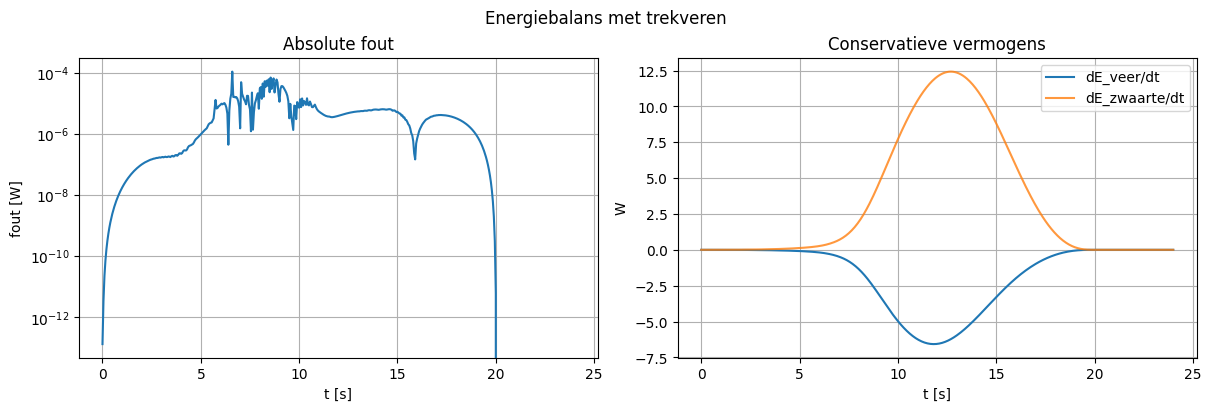

Energiebalans-validatie:
max absolute fout  = 1.069e-04 W
max relatieve fout = 6.469e-04
Negatieve dE_veer/dt tijdens openen betekent dat de veer energie teruglevert aan de schuiver.


In [8]:

# Energiebalans-validatie voor de totale oplossing (zwaartekracht + wrijving + trekveer)
# LHS: actuatorvermogen = F_s * ds
P_actuator_val = F_drive_s_total * ds

# RHS: dEkin/dt + P_zwaartekracht + P_wrijving + dE_veer/dt
links_val = [
    (masses[2], inertias[2], cg_vel[2], zero),
    (masses[3], inertias[3], cg_vel[3], dtheta3),
    (masses[4], inertias[4], cg_vel[4], dtheta4),
    (masses[5], inertias[5], cg_vel[5], dtheta5),
    (masses[6], inertias[6], cg_vel[6], dtheta6),
    (masses[7], inertias[7], cg_vel[7], dtheta7),
    (masses[8], inertias[8], cg_vel[8], dtheta8),
]

Ekin = np.zeros(n_steps)
P_gravity_val = np.zeros(n_steps)
for m_i, J_i, v_cg_i, omega_i in links_val:
    Ekin += 0.5 * m_i * np.sum(v_cg_i**2, axis=1) + 0.5 * J_i * omega_i**2
    P_gravity_val += m_i * g * v_cg_i[:, 1]

Ekin += 0.5 * payload_mass_K * np.sum(K_vel**2, axis=1)
P_gravity_val += payload_mass_K * g * K_vel[:, 1]

dEkin_dt = np.gradient(Ekin, t)

P_friction_val = -case_total["F_slider_friction_s"] * ds
P_friction_val += np.sum(case_total["joint_power_loss"], axis=1)

dE_spring_dt = spring_force_up_total * ds
energy_balance_error = P_actuator_val - (dEkin_dt + P_gravity_val + P_friction_val + dE_spring_dt)

denom_val = np.where(np.abs(P_actuator_val) > 1e-3, P_actuator_val, np.nan)
energy_balance_rel_error = np.abs(energy_balance_error / denom_val)

fig_eb, ax_eb = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_eb.suptitle("Energiebalans met trekveren")

ax_eb[0].plot(t, np.abs(energy_balance_error))
ax_eb[0].set_title("Absolute fout")
ax_eb[0].set_xlabel("t [s]"); ax_eb[0].set_ylabel("fout [W]")
ax_eb[0].set_yscale("log"); ax_eb[0].grid(True)

ax_eb[1].plot(t, dE_spring_dt, label="dE_veer/dt")
ax_eb[1].plot(t, P_gravity_val, label="dE_zwaarte/dt", alpha=0.8)
ax_eb[1].set_title("Conservatieve vermogens")
ax_eb[1].set_xlabel("t [s]"); ax_eb[1].set_ylabel("W")
ax_eb[1].grid(True); ax_eb[1].legend()

plt.show()

valid_mask = np.isfinite(energy_balance_rel_error)
print("Energiebalans-validatie:")
print(f"max absolute fout  = {np.max(np.abs(energy_balance_error)):.3e} W")
if np.any(valid_mask):
    print(f"max relatieve fout = {np.nanmax(energy_balance_rel_error):.3e}")
print("Negatieve dE_veer/dt tijdens openen betekent dat de veer energie teruglevert aan de schuiver.")


## Kracht- en energievergelijking

De nuttige vergelijking is niet alleen de veerkracht zelf, maar vooral de verandering in motorbelasting: `F_s`, actuatorvermogen, arbeid en houdkracht. De volgende grafieken tonen alleen grootheden die rechtstreeks helpen om te beoordelen of de trekveer de motor- en remkeuze verbetert.


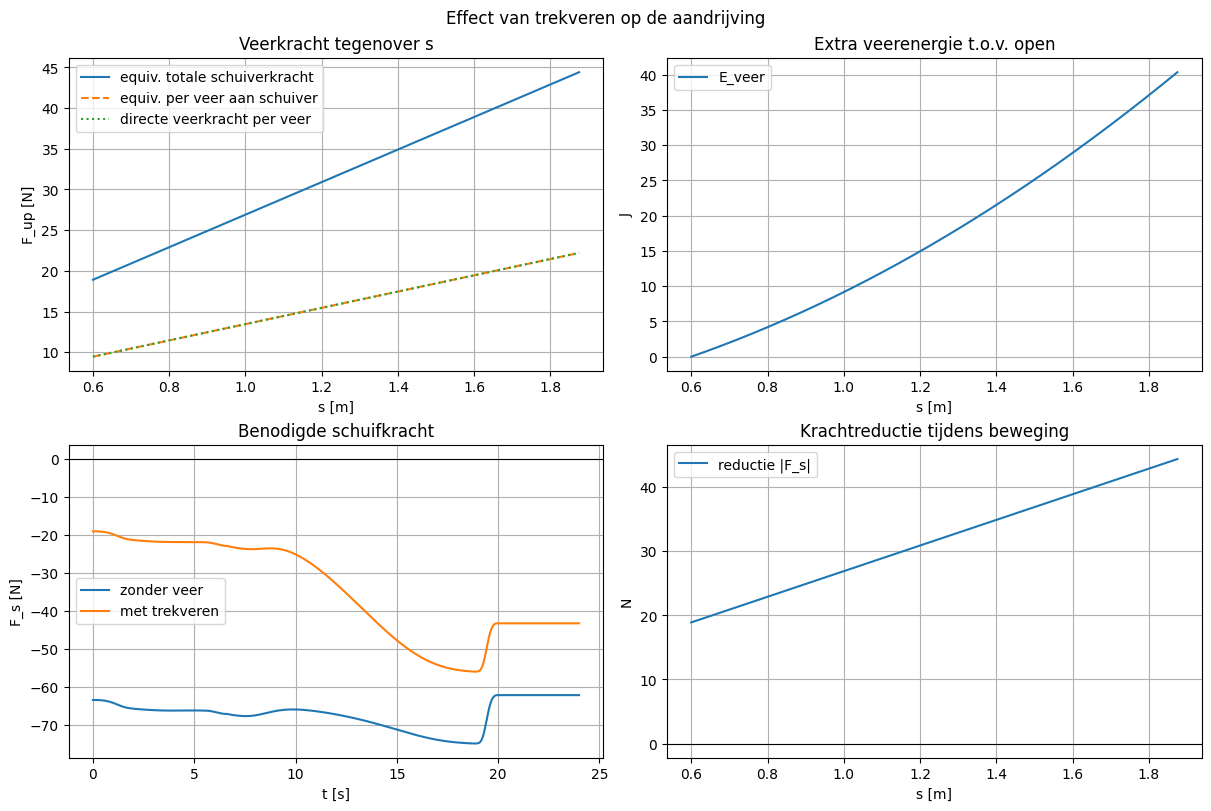

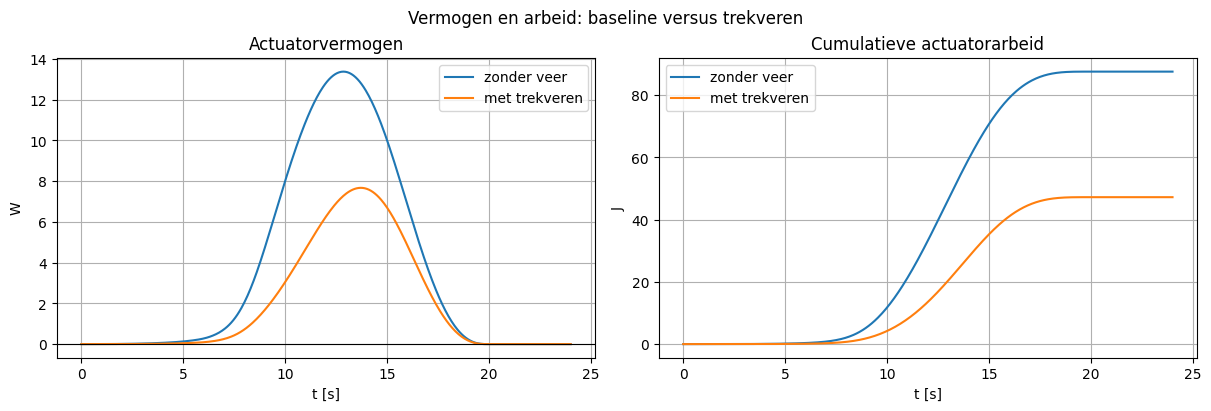

In [9]:

force_reduction_abs = np.abs(F_drive_s_baseline) - np.abs(F_drive_s_total)
P_act_total_preview = F_drive_s_total * ds
E_act_total_preview = np.zeros_like(t)
E_act_total_preview[1:] = np.cumsum(0.5 * (P_act_total_preview[1:] + P_act_total_preview[:-1]) * np.diff(t))

fig_spring, ax_spring = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_spring.suptitle("Effect van trekveren op de aandrijving")

ax_spring[0, 0].plot(hold_s_baseline_curve, spring_force_up_hold_curve, label="equiv. totale schuiverkracht")
ax_spring[0, 0].plot(hold_s_baseline_curve, spring_force_up_hold_curve / spring_count, "--", label="equiv. per veer aan schuiver")
ax_spring[0, 0].plot(hold_s_baseline_curve, spring_force_physical_hold_curve_per_spring, ":", label="directe veerkracht per veer")
ax_spring[0, 0].set_title("Veerkracht tegenover s")
ax_spring[0, 0].set_xlabel("s [m]"); ax_spring[0, 0].set_ylabel("F_up [N]")
ax_spring[0, 0].grid(True); ax_spring[0, 0].legend()

ax_spring[0, 1].plot(hold_s_baseline_curve, spring_energy_hold_curve, label="E_veer")
ax_spring[0, 1].set_title("Extra veerenergie t.o.v. open")
ax_spring[0, 1].set_xlabel("s [m]"); ax_spring[0, 1].set_ylabel("J")
ax_spring[0, 1].grid(True); ax_spring[0, 1].legend()

ax_spring[1, 0].plot(t, F_drive_s_baseline, label="zonder veer")
ax_spring[1, 0].plot(t, F_drive_s_total, label="met trekveren")
ax_spring[1, 0].axhline(0.0, color="black", lw=0.8)
ax_spring[1, 0].set_title("Benodigde schuifkracht")
ax_spring[1, 0].set_xlabel("t [s]"); ax_spring[1, 0].set_ylabel("F_s [N]")
ax_spring[1, 0].grid(True); ax_spring[1, 0].legend()

ax_spring[1, 1].plot(s_motion[sort_motion], force_reduction_abs[active_motion_mask][sort_motion], label="reductie |F_s|")
ax_spring[1, 1].axhline(0.0, color="black", lw=0.8)
ax_spring[1, 1].set_title("Krachtreductie tijdens beweging")
ax_spring[1, 1].set_xlabel("s [m]"); ax_spring[1, 1].set_ylabel("N")
ax_spring[1, 1].grid(True); ax_spring[1, 1].legend()

plt.show()

fig_power_compare, ax_power_compare = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_power_compare.suptitle("Vermogen en arbeid: baseline versus trekveren")

ax_power_compare[0].plot(t, P_act_baseline, label="zonder veer")
ax_power_compare[0].plot(t, P_act_total_preview, label="met trekveren")
ax_power_compare[0].axhline(0.0, color="black", lw=0.8)
ax_power_compare[0].set_title("Actuatorvermogen")
ax_power_compare[0].set_xlabel("t [s]"); ax_power_compare[0].set_ylabel("W")
ax_power_compare[0].grid(True); ax_power_compare[0].legend()

ax_power_compare[1].plot(t, E_act_baseline, label="zonder veer")
ax_power_compare[1].plot(t, E_act_total_preview, label="met trekveren")
ax_power_compare[1].set_title("Cumulatieve actuatorarbeid")
ax_power_compare[1].set_xlabel("t [s]"); ax_power_compare[1].set_ylabel("J")
ax_power_compare[1].grid(True); ax_power_compare[1].legend()

plt.show()


## Statische houdanalyse

De paraplu moet ook in tussenstanden kunnen blijven staan. De trekveer verlaagt de benodigde opwaartse motor-/remkracht bij openen, maar ze kan in bepaalde standen ook een neerwaartse houdvraag veroorzaken als ze meer helpt dan nodig. Daarom wordt niet alleen de piek tijdens beweging bekeken, maar ook de volledige houdcurve.


Statische houdanalyse met trekveren:
s = 0.600 m (open      ) | F_hold baseline = -62.15 N | F_hold met veer = -43.25 N | remkoppel = 2.0794 Nm
s = 0.915 m (tussenstand) | F_hold baseline = -62.96 N | F_hold met veer = -37.77 N | remkoppel = 1.8158 Nm
s = 1.238 m (tussenstand) | F_hold baseline = -63.24 N | F_hold met veer = -31.57 N | remkoppel = 1.5179 Nm
s = 1.554 m (tussenstand) | F_hold baseline = -63.37 N | F_hold met veer = -25.39 N | remkoppel = 1.2205 Nm
s = 1.875 m (gesloten  ) | F_hold baseline = -63.43 N | F_hold met veer = -19.03 N | remkoppel = 0.9149 Nm

open stand: |F_hold| baseline = 62.15 N
open stand: |F_hold| met veer = 43.25 N
max rem-/poeliekoppel baseline = 3.0496 Nm
max rem-/poeliekoppel met veer = 2.0794 Nm


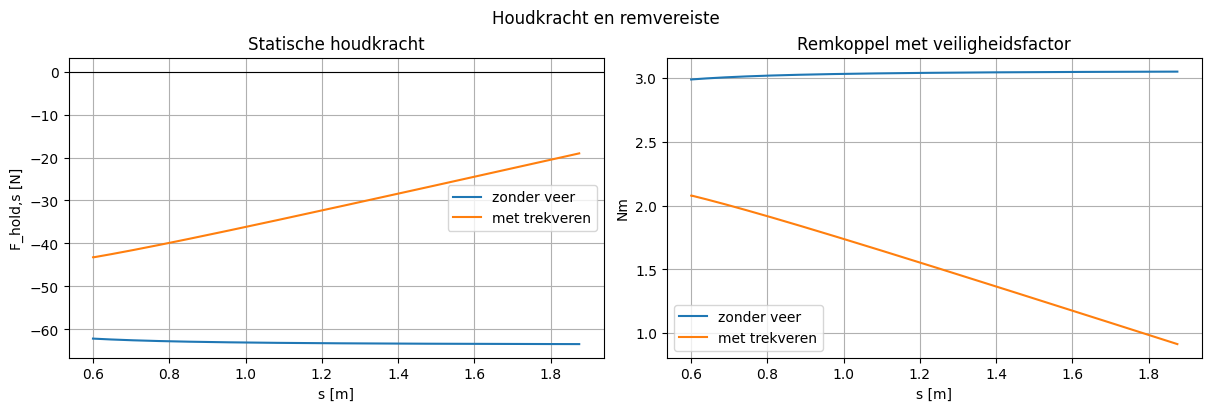

In [10]:

hold_curve_indices = np.argsort(s)
hold_s_curve = s[hold_curve_indices]
F_hold_s_curve = np.zeros_like(hold_s_curve)
R_Ax_hold_curve = np.zeros_like(hold_s_curve)
C_x_hold_curve = np.zeros_like(hold_s_curve)
C_y_hold_curve = np.zeros_like(hold_s_curve)

for out_i, k in enumerate(hold_curve_indices):
    A_hold, b_hold = build_inverse_dynamics_system(
        k,
        include_gravity=True,
        include_spring=True,
        spring_force_up=float(spring_force_up_total[k]),
        static=True,
    )
    w_hold = np.linalg.solve(A_hold, b_hold)
    F_hold_s_curve[out_i] = -w_hold[unknown_index["F_act_y"]]
    R_Ax_hold_curve[out_i] = w_hold[unknown_index["R_Ax"]]
    C_x_hold_curve[out_i] = w_hold[unknown_index["C_x"]]
    C_y_hold_curve[out_i] = w_hold[unknown_index["C_y"]]

static_slider_capacity_curve = mu_slider_static * np.abs(R_Ax_hold_curve)
T_hold_motor_curve = F_hold_s_curve * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)
T_hold_lock_required_curve = actuator_safety_factor * np.abs(F_hold_s_curve) * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)
T_hold_lock_required_baseline_curve = actuator_safety_factor * np.abs(F_hold_s_baseline_curve) * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)

sample_targets = np.linspace(np.min(s), np.max(s), 5)
sample_indices_curve = np.array([int(np.argmin(np.abs(hold_s_curve - target))) for target in sample_targets])
hold_s_values = hold_s_curve[sample_indices_curve]
F_hold_s = F_hold_s_curve[sample_indices_curve]
R_Ax_hold = R_Ax_hold_curve[sample_indices_curve]
static_slider_capacity = static_slider_capacity_curve[sample_indices_curve]
T_hold_motor = T_hold_motor_curve[sample_indices_curve]
T_hold_lock_required = T_hold_lock_required_curve[sample_indices_curve]

open_idx_curve = int(np.argmin(hold_s_curve))
closed_idx_curve = int(np.argmax(hold_s_curve))
open_idx = int(np.argmin(hold_s_values))
closed_idx = int(np.argmax(hold_s_values))

print("Statische houdanalyse met trekveren:")
for i, s_val in enumerate(hold_s_values):
    label = "open" if i == open_idx else ("gesloten" if i == closed_idx else "tussenstand")
    baseline_hold = np.interp(s_val, hold_s_baseline_curve, F_hold_s_baseline_curve)
    print(
        f"s = {s_val:.3f} m ({label:10s}) | "
        f"F_hold baseline = {baseline_hold: .2f} N | "
        f"F_hold met veer = {F_hold_s[i]: .2f} N | "
        f"remkoppel = {T_hold_lock_required[i]:.4f} Nm"
    )
print()
print(f"open stand: |F_hold| baseline = {abs(F_hold_s_baseline_curve[open_idx_baseline]):.2f} N")
print(f"open stand: |F_hold| met veer = {abs(F_hold_s_curve[open_idx_curve]):.2f} N")
print(f"max rem-/poeliekoppel baseline = {np.max(T_hold_lock_required_baseline_curve):.4f} Nm")
print(f"max rem-/poeliekoppel met veer = {np.max(T_hold_lock_required_curve):.4f} Nm")

fig_hold, ax_hold = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_hold.suptitle("Houdkracht en remvereiste")
ax_hold[0].plot(hold_s_baseline_curve, F_hold_s_baseline_curve, label="zonder veer")
ax_hold[0].plot(hold_s_curve, F_hold_s_curve, label="met trekveren")
ax_hold[0].axhline(0.0, color="black", linewidth=0.8)
ax_hold[0].set_xlabel("s [m]"); ax_hold[0].set_ylabel("F_hold,s [N]")
ax_hold[0].set_title("Statische houdkracht")
ax_hold[0].grid(True); ax_hold[0].legend()

ax_hold[1].plot(hold_s_baseline_curve, T_hold_lock_required_baseline_curve, label="zonder veer")
ax_hold[1].plot(hold_s_curve, T_hold_lock_required_curve, label="met trekveren")
ax_hold[1].set_xlabel("s [m]"); ax_hold[1].set_ylabel("Nm")
ax_hold[1].set_title("Remkoppel met veiligheidsfactor")
ax_hold[1].grid(True); ax_hold[1].legend()
plt.show()


## Vermogen en aandrijfvoorbereiding

Deze sectie berekent dezelfde grootheden als Notebook 3 voor de nieuwe belasting: kracht, vermogen, equivalent poeliekoppel en een compacte aandrijfcheck. De tijdreeksen voor kracht en vermogen zijn hierboven al getoond; hier blijft vooral de samenvattende vergelijking over die rechtstreeks naar Notebook 4 leidt.

Actuatoranalyse met trekveren:
piek schuifkracht baseline           = 74.89 N
piek schuifkracht met veer           = 55.97 N
max positief motor-ingangsvermogen   = 14.75 W
baseline positief motorvermogen      = 25.72 W
max rem/regeneratief vermogen        = 0.00 W
netto mechanische energie            = 47.23 J
energiefluctuatie                    = 47.23 J
piek motorkoppel incl. safety        = 2.6907 Nm

Compacte aandrijfcheck voor Notebook 4:
piek lijnkracht tijdens beweging     = 55.97 N
piek houdkracht over alle standen    = 43.25 N
gekozen ontwerplijnkracht            = 200.00 N
ontwerp poeliekoppel bij 25 mm       = 6.41 Nm
piek motor-ingangsvermogen ontwerp   = 19.67 W
remkoppel uitgang bij 25 mm          = 2.16 Nm


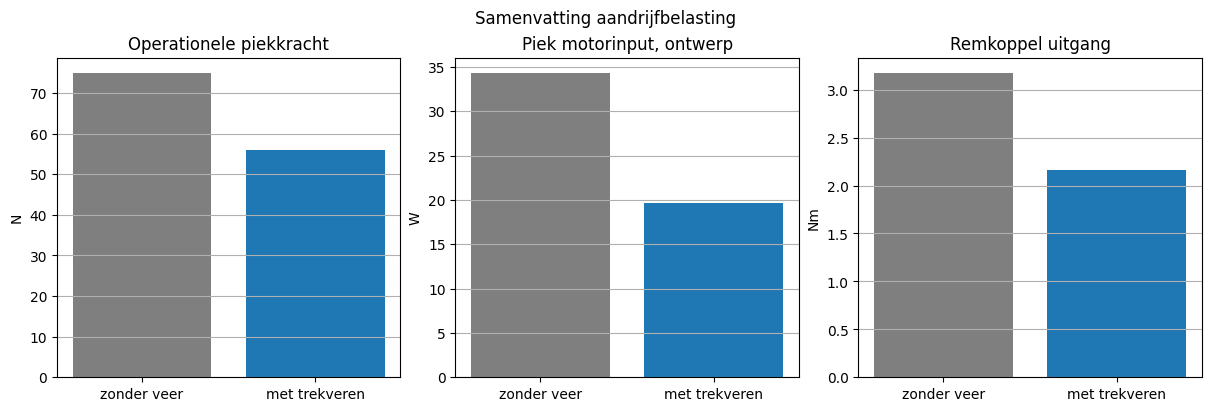

In [11]:
F_required_s_total = F_drive_s_total.copy()
P_act_total = F_required_s_total * ds
E_act_total = np.zeros_like(t)
E_act_total[1:] = np.cumsum(0.5 * (P_act_total[1:] + P_act_total[:-1]) * np.diff(t))

motor_speed_rps = ds / drive_travel_per_rev_nb3
motor_speed_rpm = 60.0 * motor_speed_rps
T_motor_total = F_required_s_total * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)
T_motor_baseline = F_drive_s_baseline * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)

motion_mask = np.abs(ds) > 1e-8
if not np.any(motion_mask):
    motion_mask = np.ones_like(ds, dtype=bool)

P_positive = np.maximum(P_act_total, 0.0)
P_negative = np.minimum(P_act_total, 0.0)
P_positive_peak = actuator_safety_factor * np.max(P_positive) / actuator_efficiency
P_regen_peak = actuator_safety_factor * abs(np.min(P_negative)) * actuator_efficiency
T_motor_peak = actuator_safety_factor * np.max(np.abs(T_motor_total))
T_motor_rms = actuator_safety_factor * np.sqrt(np.mean(T_motor_total[motion_mask]**2))
F_total_peak = np.max(np.abs(F_required_s_total[motion_mask]))
F_total_rms = np.sqrt(np.mean(F_required_s_total[motion_mask]**2))
energy_net_total = E_act_total[-1] - E_act_total[0]
energy_fluctuation_total = np.max(E_act_total) - np.min(E_act_total)

P_positive_baseline = np.maximum(P_act_baseline, 0.0)
P_positive_peak_baseline = actuator_safety_factor * np.max(P_positive_baseline) / actuator_efficiency
F_total_peak_baseline = np.max(np.abs(F_drive_s_baseline[motion_mask]))

quick_drive_efficiency = 0.78
quick_drive_safety_factor = 2.0
quick_brake_safety_factor = 2.0
quick_pulley_radius = 0.025
quick_line_force_floor = 200.0

quick_line_force_peak_motion_baseline = float(np.max(np.abs(F_drive_s_baseline[motion_mask])))
quick_line_force_peak_hold_baseline = float(np.max(np.abs(F_hold_s_baseline_curve)))
quick_line_force_peak_operating_baseline = max(quick_line_force_peak_motion_baseline, quick_line_force_peak_hold_baseline)
quick_line_force_design_baseline = max(quick_drive_safety_factor * quick_line_force_peak_operating_baseline, quick_line_force_floor)
quick_T_pulley_design_baseline = quick_line_force_design_baseline * quick_pulley_radius / quick_drive_efficiency
quick_P_peak_motor_input_baseline = quick_drive_safety_factor * float(np.max(P_positive_baseline[motion_mask])) / quick_drive_efficiency
quick_T_hold_design_baseline = quick_brake_safety_factor * quick_line_force_peak_hold_baseline * quick_pulley_radius

quick_line_force_peak_motion = float(np.max(np.abs(F_required_s_total[motion_mask])))
quick_line_force_peak_hold = float(np.max(np.abs(F_hold_s_curve)))
quick_line_force_peak_operating = max(quick_line_force_peak_motion, quick_line_force_peak_hold)
quick_line_force_design = max(quick_drive_safety_factor * quick_line_force_peak_operating, quick_line_force_floor)
quick_T_pulley_design = quick_line_force_design * quick_pulley_radius / quick_drive_efficiency
quick_P_peak_motor_input = quick_drive_safety_factor * float(np.max(P_positive[motion_mask])) / quick_drive_efficiency
quick_T_hold_design = quick_brake_safety_factor * quick_line_force_peak_hold * quick_pulley_radius

print("Actuatoranalyse met trekveren:")
print(f"piek schuifkracht baseline           = {F_total_peak_baseline:.2f} N")
print(f"piek schuifkracht met veer           = {F_total_peak:.2f} N")
print(f"max positief motor-ingangsvermogen   = {P_positive_peak:.2f} W")
print(f"baseline positief motorvermogen      = {P_positive_peak_baseline:.2f} W")
print(f"max rem/regeneratief vermogen        = {P_regen_peak:.2f} W")
print(f"netto mechanische energie            = {energy_net_total:.2f} J")
print(f"energiefluctuatie                    = {energy_fluctuation_total:.2f} J")
print(f"piek motorkoppel incl. safety        = {T_motor_peak:.4f} Nm")
print()
print("Compacte aandrijfcheck voor Notebook 4:")
print(f"piek lijnkracht tijdens beweging     = {quick_line_force_peak_motion:.2f} N")
print(f"piek houdkracht over alle standen    = {quick_line_force_peak_hold:.2f} N")
print(f"gekozen ontwerplijnkracht            = {quick_line_force_design:.2f} N")
print(f"ontwerp poeliekoppel bij 25 mm       = {quick_T_pulley_design:.2f} Nm")
print(f"piek motor-ingangsvermogen ontwerp   = {quick_P_peak_motor_input:.2f} W")
print(f"remkoppel uitgang bij 25 mm          = {quick_T_hold_design:.2f} Nm")

fig_quick, ax_quick = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
fig_quick.suptitle("Samenvatting aandrijfbelasting")
labels = ["zonder veer", "met trekveren"]
colors = ["tab:gray", "tab:blue"]

ax_quick[0].bar(labels, [quick_line_force_peak_operating_baseline, quick_line_force_peak_operating], color=colors)
ax_quick[0].set_title("Operationele piekkracht")
ax_quick[0].set_ylabel("N")
ax_quick[0].grid(True, axis="y")

ax_quick[1].bar(labels, [quick_P_peak_motor_input_baseline, quick_P_peak_motor_input], color=colors)
ax_quick[1].set_title("Piek motorinput, ontwerp")
ax_quick[1].set_ylabel("W")
ax_quick[1].grid(True, axis="y")

ax_quick[2].bar(labels, [quick_T_hold_design_baseline, quick_T_hold_design], color=colors)
ax_quick[2].set_title("Remkoppel uitgang")
ax_quick[2].set_ylabel("Nm")
ax_quick[2].grid(True, axis="y")

plt.show()

## Arbeids-surplus

Een trekveer is een energieopslag in parallel met de aandrijving. Ze verlaagt de motorlast tijdens openen door eerder opgeslagen energie vrij te geven. Die energie moet bij sluiten opnieuw in de veer gestoken worden. De arbeids-surplusgrafiek toont daarom niet alleen de piekbelasting, maar ook hoe de energie over het traject verschuift.


  ARBEIDS-SURPLUS MET TREKVEREN 
Gemiddeld ingangsvermogen  P_avg  = 1.964 W
Piek    ingangsvermogen    P_peak = 7.671 W
RMS     ingangsvermogen    P_rms  = 3.307 W
Piek    aandrijfkracht     F_peak = 55.968 N
RMS     aandrijfkracht     F_rms  = 35.629 N
Arbeids-surplus baseline          = 50.0525 J
Arbeids-surplus met trekveren     = 27.4402 J
Extra veerenergie gesloten-open   = 40.3567 J

Tandriem/poelie quick check (r_ref = 25.0 mm, eta = 0.78):
  Piek motorkoppel  (x1.5) = 2.6907 Nm
  RMS  motorkoppel  (x1.5) = 1.7129 Nm


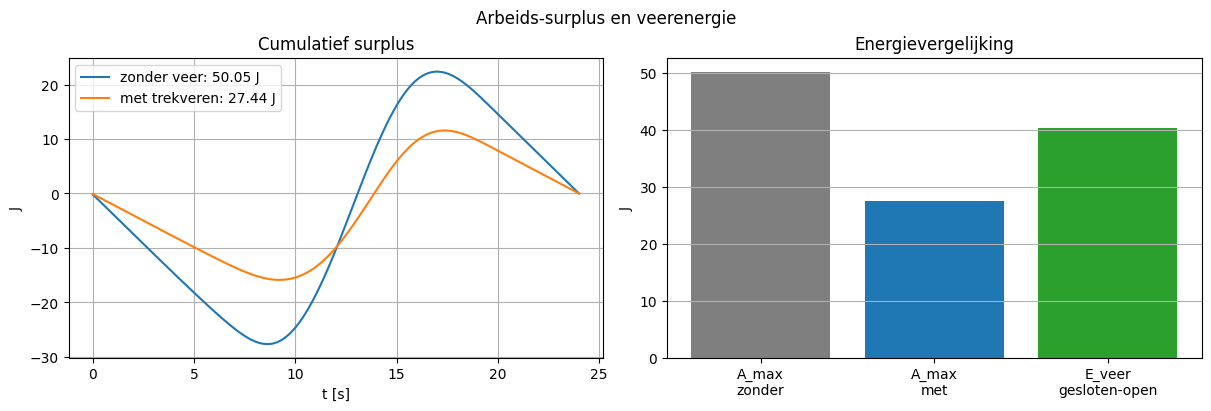

In [12]:
P_load_full = F_required_s_total * ds
P_avg_full = P_load_full.mean()
P_peak_full = np.abs(P_load_full).max()
P_rms_full = np.sqrt(np.mean(P_load_full**2))
F_peak_full = np.abs(F_required_s_total[motion_mask]).max()
F_rms_full = np.sqrt(np.mean(F_required_s_total[motion_mask]**2))

A_theta_full = np.cumsum((P_load_full - P_avg_full) * Ts)
A_max_full = A_theta_full.max() - A_theta_full.min()

T_motor_peak_sizing = actuator_safety_factor * F_peak_full * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)
T_motor_rms_sizing = actuator_safety_factor * F_rms_full * drive_travel_per_rev_nb3 / (2 * np.pi * actuator_efficiency)
P_motor_rated_req = 1.5 * P_rms_full
P_motor_peak_req = 1.3 * P_peak_full

A_theta_baseline = np.cumsum((P_act_baseline - np.mean(P_act_baseline)) * Ts)
A_max_baseline = A_theta_baseline.max() - A_theta_baseline.min()

print("=" * 62)
print("  ARBEIDS-SURPLUS MET TREKVEREN ")
print("=" * 62)
print(f"Gemiddeld ingangsvermogen  P_avg  = {P_avg_full:.3f} W")
print(f"Piek    ingangsvermogen    P_peak = {P_peak_full:.3f} W")
print(f"RMS     ingangsvermogen    P_rms  = {P_rms_full:.3f} W")
print(f"Piek    aandrijfkracht     F_peak = {F_peak_full:.3f} N")
print(f"RMS     aandrijfkracht     F_rms  = {F_rms_full:.3f} N")
print(f"Arbeids-surplus baseline          = {A_max_baseline:.4f} J")
print(f"Arbeids-surplus met trekveren     = {A_max_full:.4f} J")
print(f"Extra veerenergie gesloten-open   = {spring_energy_delta:.4f} J")
print()
print(f"Tandriem/poelie quick check (r_ref = {drive_pulley_radius_nb3*1000:.1f} mm, eta = {actuator_efficiency:.2f}):")
print(f"  Piek motorkoppel  (x{actuator_safety_factor:.1f}) = {T_motor_peak_sizing:.4f} Nm")
print(f"  RMS  motorkoppel  (x{actuator_safety_factor:.1f}) = {T_motor_rms_sizing:.4f} Nm")

fig_amax, ax_amax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
fig_amax.suptitle("Arbeids-surplus en veerenergie")

ax_amax[0].plot(t, A_theta_baseline, label=f"zonder veer: {A_max_baseline:.2f} J")
ax_amax[0].plot(t, A_theta_full, label=f"met trekveren: {A_max_full:.2f} J")
ax_amax[0].set_title("Cumulatief surplus")
ax_amax[0].set_xlabel("t [s]"); ax_amax[0].set_ylabel("J")
ax_amax[0].grid(True); ax_amax[0].legend()

energy_labels = ["A_max\nzonder", "A_max\nmet", "E_veer\ngesloten-open"]
energy_values = [A_max_baseline, A_max_full, spring_energy_delta]
ax_amax[1].bar(energy_labels, energy_values, color=["tab:gray", "tab:blue", "tab:green"])
ax_amax[1].set_title("Energievergelijking")
ax_amax[1].set_ylabel("J")
ax_amax[1].grid(True, axis="y")

plt.show()

## Framebelasting

De veer verlaagt de motor-/riemkracht, maar de veer verdwijnt mechanisch niet. Ze trekt omhoog aan de schuiver en omlaag aan haar vaste anker in de mast of het frame. De riem moet die veerkracht niet dragen, maar de schuiver/collar en het veeranker moeten wel correct gedimensioneerd worden.

De netto frame-resultante volgt dezelfde conventie als Notebook 3: de steun- en bekende externe krachten op het mechanisme worden samengeteld. De aparte kracht op het veeranker wordt daarnaast getoond als lokale mast-/ankerbelasting, niet nog eens extra opgeteld in dezelfde resultante.

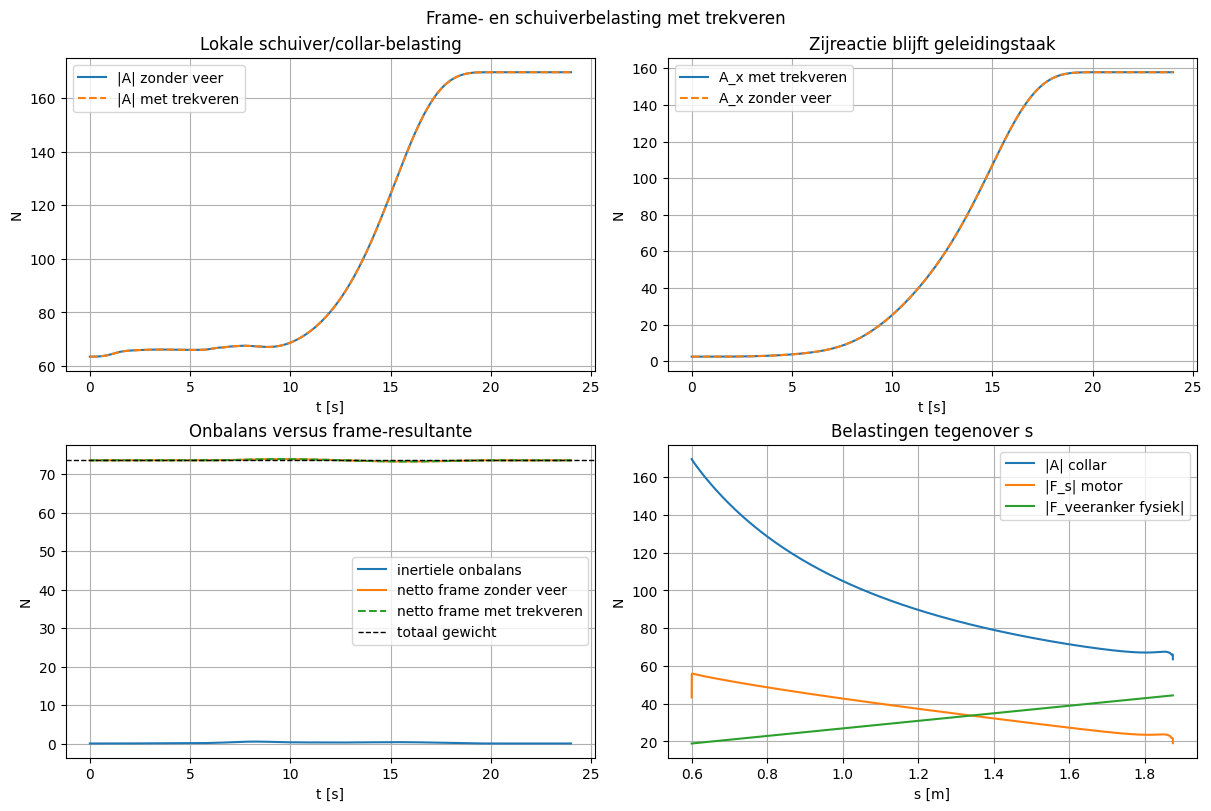

Framebelasting met trekveren:
totaal gewicht model                  = 73.57 N
max netto frame-resultante baseline   = 73.90 N
max netto frame-resultante met veer   = 73.90 N
max frame-reactie aan C               = 158.27 N
max lokale schuiver/collar-belasting  = 169.65 N
max zijreactie A_x                    = 157.86 N
max equivalente veerankerbelasting    = 44.40 N
max fysieke trekveer-/ankerbelasting  = 44.40 N
De veer verlaagt de motorlast, maar niet de grote horizontale geleidingsreactie.


In [13]:
F_slider_global = np.column_stack((np.zeros(n_steps), -case_total["F_slider_friction_s"]))
F_spring_global = np.column_stack((np.zeros(n_steps), spring_force_up_total))
F_spring_anchor_global = -F_spring_global
F_spring_anchor_norm = np.linalg.norm(F_spring_anchor_global, axis=1)
F_spring_physical_anchor_global = np.column_stack((np.zeros(n_steps), -spring_force_physical_total))
F_spring_physical_anchor_norm = np.linalg.norm(F_spring_physical_anchor_global, axis=1)

# Lokale belasting aan de schuiver/collar: actuator + geleiding + wrijving + veer op de schuiver.
F_A_total = np.column_stack((vars_total["R_Ax"], vars_total["F_act_y"])) + F_slider_global + F_spring_global
F_C_total = np.column_stack((vars_total["C_x"], vars_total["C_y"]))

# Zelfde conventie als Notebook 3: totale steun-/externe belasting op het mechanisme.
# De tegengestelde veerankerbelasting wordt apart gerapporteerd als lokale ankerlast.
F_frame_total = F_A_total + F_C_total
F_frame_total_norm = np.linalg.norm(F_frame_total, axis=1)
F_C_total_norm = np.linalg.norm(F_C_total, axis=1)
F_A_total_norm = np.linalg.norm(F_A_total, axis=1)
total_weight = total_model_mass * g

if "F_shak_norm" in dyn.files:
    F_shak_norm_inertia = dyn["F_shak_norm"]
else:
    F_shak_norm_inertia = np.linalg.norm(np.column_stack((dyn.get("F_shak_x", np.zeros(n_steps)), dyn.get("F_shak_y", np.zeros(n_steps)))), axis=1)

fig_frame, ax_frame = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
fig_frame.suptitle("Frame- en schuiverbelasting met trekveren")
ax_frame[0, 0].plot(t, F_A_baseline_norm, label="|A| zonder veer")
ax_frame[0, 0].plot(t, F_A_total_norm, "--", label="|A| met trekveren")
ax_frame[0, 0].set_title("Lokale schuiver/collar-belasting")
ax_frame[0, 0].set_xlabel("t [s]"); ax_frame[0, 0].set_ylabel("N")
ax_frame[0, 0].grid(True); ax_frame[0, 0].legend()

ax_frame[0, 1].plot(t, vars_total["R_Ax"], label="A_x met trekveren")
ax_frame[0, 1].plot(t, R_Ax_baseline, "--", label="A_x zonder veer")
ax_frame[0, 1].set_title("Zijreactie blijft geleidingstaak")
ax_frame[0, 1].set_xlabel("t [s]"); ax_frame[0, 1].set_ylabel("N")
ax_frame[0, 1].grid(True); ax_frame[0, 1].legend()

ax_frame[1, 0].plot(t, F_shak_norm_inertia, label="inertiele onbalans")
ax_frame[1, 0].plot(t, F_frame_baseline_norm, label="netto frame zonder veer")
ax_frame[1, 0].plot(t, F_frame_total_norm, "--", label="netto frame met trekveren")
ax_frame[1, 0].axhline(total_weight, color="black", linestyle="--", linewidth=1.0, label="totaal gewicht")
ax_frame[1, 0].set_title("Onbalans versus frame-resultante")
ax_frame[1, 0].set_xlabel("t [s]"); ax_frame[1, 0].set_ylabel("N")
ax_frame[1, 0].grid(True); ax_frame[1, 0].legend()

ax_frame[1, 1].plot(s_motion[sort_motion], F_A_total_norm[active_motion_mask][sort_motion], label="|A| collar")
ax_frame[1, 1].plot(s_motion[sort_motion], np.abs(F_required_s_total[active_motion_mask][sort_motion]), label="|F_s| motor")
ax_frame[1, 1].plot(s_motion[sort_motion], F_spring_physical_anchor_norm[active_motion_mask][sort_motion], label="|F_veeranker fysiek|")
ax_frame[1, 1].set_title("Belastingen tegenover s")
ax_frame[1, 1].set_xlabel("s [m]"); ax_frame[1, 1].set_ylabel("N")
ax_frame[1, 1].grid(True); ax_frame[1, 1].legend()
plt.show()

print("Framebelasting met trekveren:")
print(f"totaal gewicht model                  = {total_weight:.2f} N")
print(f"max netto frame-resultante baseline   = {np.max(F_frame_baseline_norm):.2f} N")
print(f"max netto frame-resultante met veer   = {np.max(F_frame_total_norm):.2f} N")
print(f"max frame-reactie aan C               = {np.max(F_C_total_norm):.2f} N")
print(f"max lokale schuiver/collar-belasting  = {np.max(F_A_total_norm):.2f} N")
print(f"max zijreactie A_x                    = {np.max(np.abs(vars_total['R_Ax'])):.2f} N")
print(f"max equivalente veerankerbelasting    = {np.max(F_spring_anchor_norm):.2f} N")
print(f"max fysieke trekveer-/ankerbelasting  = {np.max(F_spring_physical_anchor_norm):.2f} N")
print("De veer verlaagt de motorlast, maar niet de grote horizontale geleidingsreactie.")

## Opslag

De resultaten worden opgeslagen in `notebook3_trekveren_results.npz`. De hoofdkeys zijn compatibel met Notebook 4. Extra keys beschrijven het trekveerpakket, de baselinevergelijking en de compacte aandrijfcheck.


## Interpretatie

De trekveer is vooral zinvol als de piekbelasting tijdens openen of de houdkracht in kritische standen te groot wordt. Ze is geen gratis energiewinst: bij sluiten moet de veer opnieuw opgespannen worden. De juiste beoordeling is daarom:

- verlaagt de veer de piekkracht en het piekvermogen genoeg om een kleinere of rustiger motor te kiezen;
- blijft de motor/rem in alle tussenstanden controle houden;
- blijven schuivergeleiding, mast en veeranker realistisch belast;
- blijft de veer ondergecompenseerd, zodat het mechanisme niet vanzelf ongecontroleerd open wil trekken.


In [14]:

results_path = Path("notebook3_trekveren_results.npz").resolve()
np.savez(
    results_path,
    t=t, s=s, ds=ds, dds=dds,
    F_drive_s_inertia=F_drive_s_inertia,
    F_drive_s_gravity=F_drive_s_gravity,
    F_drive_s_gravity_spring=F_drive_s_gravity,
    F_drive_s_total=F_drive_s_total,
    F_gravity_component=F_gravity_component,
    F_gravity_spring_component=F_gravity_component,
    F_friction_component=F_friction_component,
    F_slider_drive_component=F_slider_drive_component,
    F_pin_friction_component=F_pin_friction_component,
    F_slider_friction_s=case_total["F_slider_friction_s"],
    N_slider=case_total["N_slider"],
    joint_friction_moments=case_total["joint_friction_moments"],
    joint_normal_forces=case_total["joint_normal_forces"],
    joint_power_loss=case_total["joint_power_loss"],
    pin_joint_names=np.array(pin_joint_names),
    R_Ax_total=vars_total["R_Ax"],
    C_x_total=vars_total["C_x"],
    C_y_total=vars_total["C_y"],
    M_A_total=vars_total["M_A"],
    F_A_total=F_A_total,
    F_C_total=F_C_total,
    F_frame_total=F_frame_total,
    F_spring_global=F_spring_global,
    F_spring_anchor_global=F_spring_anchor_global,
    F_spring_anchor_norm=F_spring_anchor_norm,
    F_spring_physical_anchor_global=F_spring_physical_anchor_global,
    F_spring_physical_anchor_norm=F_spring_physical_anchor_norm,
    F_A_total_norm=F_A_total_norm,
    F_C_total_norm=F_C_total_norm,
    F_frame_total_norm=F_frame_total_norm,
    P_act_total=P_act_total,
    E_act_total=E_act_total,
    T_motor_total=T_motor_total,
    motor_speed_rpm=motor_speed_rpm,
    hold_s_values=hold_s_values,
    F_hold_s=F_hold_s,
    R_Ax_hold=R_Ax_hold,
    static_slider_capacity=static_slider_capacity,
    hold_s_curve=hold_s_curve,
    F_hold_s_curve=F_hold_s_curve,
    R_Ax_hold_curve=R_Ax_hold_curve,
    static_slider_capacity_curve=static_slider_capacity_curve,
    T_hold_motor=T_hold_motor,
    T_hold_lock_required=T_hold_lock_required,
    T_hold_motor_curve=T_hold_motor_curve,
    T_hold_lock_required_curve=T_hold_lock_required_curve,
    A_max_full=A_max_full,
    A_theta_full=A_theta_full,
    P_avg_full=P_avg_full,
    P_peak_full=P_peak_full,
    P_rms_full=P_rms_full,
    F_peak_full=F_peak_full,
    F_rms_full=F_rms_full,
    T_motor_peak_sizing=T_motor_peak_sizing,
    T_motor_rms_sizing=T_motor_rms_sizing,
    energy_balance_error=energy_balance_error,
    Ekin=Ekin,
    masses=np.array([masses[i] for i in range(2, 9)]),
    inertias=np.array([inertias[i] for i in range(2, 9)]),
    payload_mass_K=payload_mass_K,
    line_mass_density=line_mass_density,
    slider_mass=slider_mass,
    rod_outer_diameter=rod_outer_diameter,
    rod_wall_thickness=rod_wall_thickness,
    rod_inner_diameter=rod_inner_diameter,
    rod_material_density=rod_material_density,
    rod_tube_area=rod_tube_area,
    rod_tube_mass_per_m=rod_tube_mass_per_m,
    rod_fittings_line_mass_allowance=rod_fittings_line_mass_allowance,
    total_model_mass=total_model_mass,
    g=g,
    mu_slider=mu_slider,
    mu_slider_static=mu_slider_static,
    c_slider=c_slider,
    mu_pin=mu_pin,
    pin_radius=pin_radius,
    actuator_efficiency=actuator_efficiency,
    actuator_safety_factor=actuator_safety_factor,
    drive_pulley_radius_nb3=drive_pulley_radius_nb3,
    drive_travel_per_rev_nb3=drive_travel_per_rev_nb3,
    pulley_radius_nb3=pulley_radius_nb3,
    screw_lead=screw_lead,
    total_weight=total_weight,
    dyn_residual_total=case_total["residual"],
    dyn_cond_total=case_total["cond"],
    max_diff_notebook2=max_diff_notebook2,
    load_case=np.array("trekveren"),
    baseline_results3_filename=np.array(str(baseline_path.name)),
    spring_count=spring_count,
    spring_design_mode=np.array(spring_design_mode),
    spring_assist_fraction_open=spring_assist_fraction_open,
    spring_assist_fraction_closed=spring_assist_fraction_closed,
    spring_max_assist_fraction=spring_max_assist_fraction,
    spring_scale_factor=spring_scale_factor,
    spring_force_up_total=spring_force_up_total,
    spring_force_s_total=spring_force_s_total,
    spring_force_up_hold_curve=spring_force_up_hold_curve,
    spring_force_s_hold_curve=spring_force_s_hold_curve,
    spring_force_open_total=spring_force_open_total,
    spring_force_closed_total=spring_force_closed_total,
    spring_force_open_per_spring=spring_force_open_per_spring,
    spring_force_closed_per_spring=spring_force_closed_per_spring,
    spring_k_total=spring_k_total,
    spring_k_per_spring=spring_k_per_spring,
    spring_physical_rate_per_spring_N_per_mm=spring_physical_rate_per_spring_N_per_mm,
    spring_physical_rate_per_spring=spring_physical_rate_per_spring,
    spring_physical_model=np.array("direct_linear_spring"),
    spring_motion_ratio=spring_motion_ratio,
    spring_physical_extension=spring_physical_extension,
    spring_physical_extension_hold_curve=spring_physical_extension_hold_curve,
    spring_physical_extension_closed=spring_physical_extension_closed,
    spring_physical_preload_extension=spring_physical_preload_extension,
    spring_initial_tension_per_spring=spring_initial_tension_per_spring,
    spring_force_physical_per_spring=spring_force_physical_per_spring,
    spring_force_physical_hold_curve_per_spring=spring_force_physical_hold_curve_per_spring,
    spring_force_open_physical_per_spring=spring_force_open_physical_per_spring,
    spring_force_closed_physical_per_spring=spring_force_closed_physical_per_spring,
    spring_force_physical_total=spring_force_physical_total,
    spring_energy_stored=spring_energy_stored,
    spring_energy_hold_curve=spring_energy_hold_curve,
    spring_energy_delta=spring_energy_delta,
    spring_assist_fraction_curve=spring_assist_fraction_curve,
    F_drive_s_baseline=F_drive_s_baseline,
    F_drive_s_gravity_baseline=F_drive_s_gravity_baseline,
    F_gravity_component_baseline=F_gravity_component_baseline,
    F_spring_assist_component=F_spring_assist_component,
    F_hold_s_baseline_curve=F_hold_s_baseline_curve,
    P_act_baseline=P_act_baseline,
    E_act_baseline=E_act_baseline,
    opening_peak_reduction=opening_peak_reduction,
    opening_peak_reduction_pct=opening_peak_reduction_pct,
    quick_line_force_peak_motion_baseline=quick_line_force_peak_motion_baseline,
    quick_line_force_peak_hold_baseline=quick_line_force_peak_hold_baseline,
    quick_line_force_design_baseline=quick_line_force_design_baseline,
    quick_T_pulley_design_baseline=quick_T_pulley_design_baseline,
    quick_P_peak_motor_input_baseline=quick_P_peak_motor_input_baseline,
    quick_T_hold_design_baseline=quick_T_hold_design_baseline,
    quick_line_force_peak_motion=quick_line_force_peak_motion,
    quick_line_force_peak_hold=quick_line_force_peak_hold,
    quick_line_force_design=quick_line_force_design,
    quick_T_pulley_design=quick_T_pulley_design,
    quick_P_peak_motor_input=quick_P_peak_motor_input,
    quick_T_hold_design=quick_T_hold_design,
)

print("Notebook 3 - Trekveren-resultaten opgeslagen in:")
print(results_path)
print()
print("SAMENVATTING")
print("=" * 56)
print(f"max |F_s| baseline                  : {np.max(np.abs(F_drive_s_baseline[active_motion_mask])):.2f} N")
print(f"max |F_s| met trekveren             : {np.max(np.abs(F_drive_s_total[active_motion_mask])):.2f} N")
print(f"piekreductie bij openen             : {opening_peak_reduction:.2f} N ({opening_peak_reduction_pct:.1f} %)")
print(f"open stand |F_hold| baseline         : {abs(F_hold_s_baseline_curve[open_idx_baseline]):.2f} N")
print(f"open stand |F_hold| met veer         : {abs(F_hold_s_curve[open_idx_curve]):.2f} N")
print(f"veerenergie gesloten-open           : {spring_energy_delta:.2f} J")
print(f"piek actuatorvermogen met veer       : {P_positive_peak:.2f} W")
print(f"quick ontwerplijnkracht Notebook 4   : {quick_line_force_design:.2f} N")
print(f"quick poeliekoppel bij 25 mm         : {quick_T_pulley_design:.2f} Nm")
print(f"max steunreactie schuiver/collar     : {np.max(F_A_total_norm):.2f} N")
print(f"arbeids-surplus met trekveren        : {A_max_full:.4f} J")
print(f"max energiebalans-fout               : {np.max(np.abs(energy_balance_error)):.3e} W")
print(f"validatie t.o.v. Notebook 2          : {max_diff_notebook2:.3e} N")


Notebook 3 - Trekveren-resultaten opgeslagen in:
C:\Users\WELL_ASUS_BUP\OneDrive\Alexandre\KUL\Semester 6\Beweging\Bewegingen-trillingen-project\project\notebooks\Stangen\notebook3_trekveren_results.npz

SAMENVATTING
max |F_s| baseline                  : 74.89 N
max |F_s| met trekveren             : 55.97 N
piekreductie bij openen             : 18.92 N (25.3 %)
open stand |F_hold| baseline         : 62.15 N
open stand |F_hold| met veer         : 43.25 N
veerenergie gesloten-open           : 40.36 J
piek actuatorvermogen met veer       : 14.75 W
quick ontwerplijnkracht Notebook 4   : 200.00 N
quick poeliekoppel bij 25 mm         : 6.41 Nm
max steunreactie schuiver/collar     : 169.65 N
arbeids-surplus met trekveren        : 27.4402 J
max energiebalans-fout               : 1.069e-04 W
validatie t.o.v. Notebook 2          : 0.000e+00 N
